In [1]:
import xarray as xr
import matplotlib.pyplot as plt 
import seaborn as sns
import cartopy.crs as ccrs
import seaborn.objects as so
import numpy as np
from dask.distributed import LocalCluster, Client
import flox.xarray
import xesmf as xe
from affine import Affine

from tqdm.notebook import tqdm
import scipy
import dask.bag as db
from pyproj import Proj, Transformer, CRS
import geopandas as gpd
from rasterio import features
from shapely.geometry import shape

import pandas as pd
plt.style.use('robin')
from matplotlib.colors import LogNorm, Normalize
proj = ccrs.NorthPolarStereo(0,70)
import dask.bag as db

def sigmoid(x):
    return 1/(1+np.exp(-x))

In [2]:
cluster = LocalCluster(n_workers=4, memory_limit='12GiB')
client = Client(cluster)
client

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 33591 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:33591/status,
Dashboard: http://127.0.0.1:33591/status,Workers: 4
Total threads: 64,Total memory: 48.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38603,Workers: 0
Dashboard: http://127.0.0.1:33591/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:42105,Total threads: 16
Dashboard: http://127.0.0.1:43397/status,Memory: 12.00 GiB
Nanny: tcp://127.0.0.1:44489,


# Load experiments results

In [3]:
# run_id = '3w874ud3'
# run_id = '0obl1joe'
# run_id = '75kakckt'
# run_id = 'wisxbydg'
# run_id = 'bd4apy6o'
run_id ='ima3ba04'

# ds_attrs = xr.open_dataset(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_attributions.nc', chunks = dict(time_of_event=20)).load()
ds_attrs = xr.open_dataset(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_ALL_attributions_v2.nc', chunks = dict(time_of_event=20)).load().transpose('y','x',...)

# ds_moran = xr.open_dataset(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_moranI_lrp_normed_v2.nc') 
# ds_attrs['moran_I'] = ds_moran.Moran_I

grid = ds_attrs.isel(time_of_event=0, timestep_past=0, var_name=0).attributions_lrp
lrp_normed = ds_attrs.attributions_lrp 
lrp_normed = lrp_normed.sum('var_name')/lrp_normed.sum('var_name').clip(0).sum(['x','y'])
ds_attrs['lrp_normed'] = lrp_normed
# ig_normed = ds_attrs.attributions_ig 
# ig_normed = ig_normed/ig_normed.sum('var_name').max(['x','y'])
# cycs = cycs.query("msl<100000")
ds_attrs

<xarray.Dataset> Size: 2GB
Dimensions:           (time_of_event: 840, y: 128, x: 128, timestep_past: 7,
                       var_name: 3)
Coordinates:
    quantile          float64 8B 0.95
  * x                 (x) float64 1kB -1e+07 -9.882e+06 ... 4.882e+06 5e+06
  * y                 (y) float64 1kB -1e+07 -9.882e+06 ... 4.882e+06 5e+06
  * var_name          (var_name) <U4 48B 'u850' 'v850' 'msl'
    lat               (y, x) float32 66kB -7.882 -7.545 -7.207 ... 31.09 30.5
    lon               (y, x) float32 66kB -45.0 -44.66 -44.32 ... 135.7 135.0
  * timestep_past     (timestep_past) int64 56B -6 -5 -4 -3 -2 -1 0
  * time_of_event     (time_of_event) datetime64[ns] 7kB 1979-01-07 ... 2024-...
Data variables:
    rain              (time_of_event) float64 7kB 30.89 37.58 ... 31.53 28.58
    targets           (time_of_event) float64 7kB 1.0 1.0 1.0 ... 1.0 1.0 1.0
    attributions_lrp  (y, x, time_of_event, timestep_past, var_name) float32 1GB ...
    predictions       (time_of_event, timestep_past) float32 24kB 1.192 ... 4...
    lrp_normed        (y, x, time_of_event, timestep_past) float32 385MB 0.0 ...

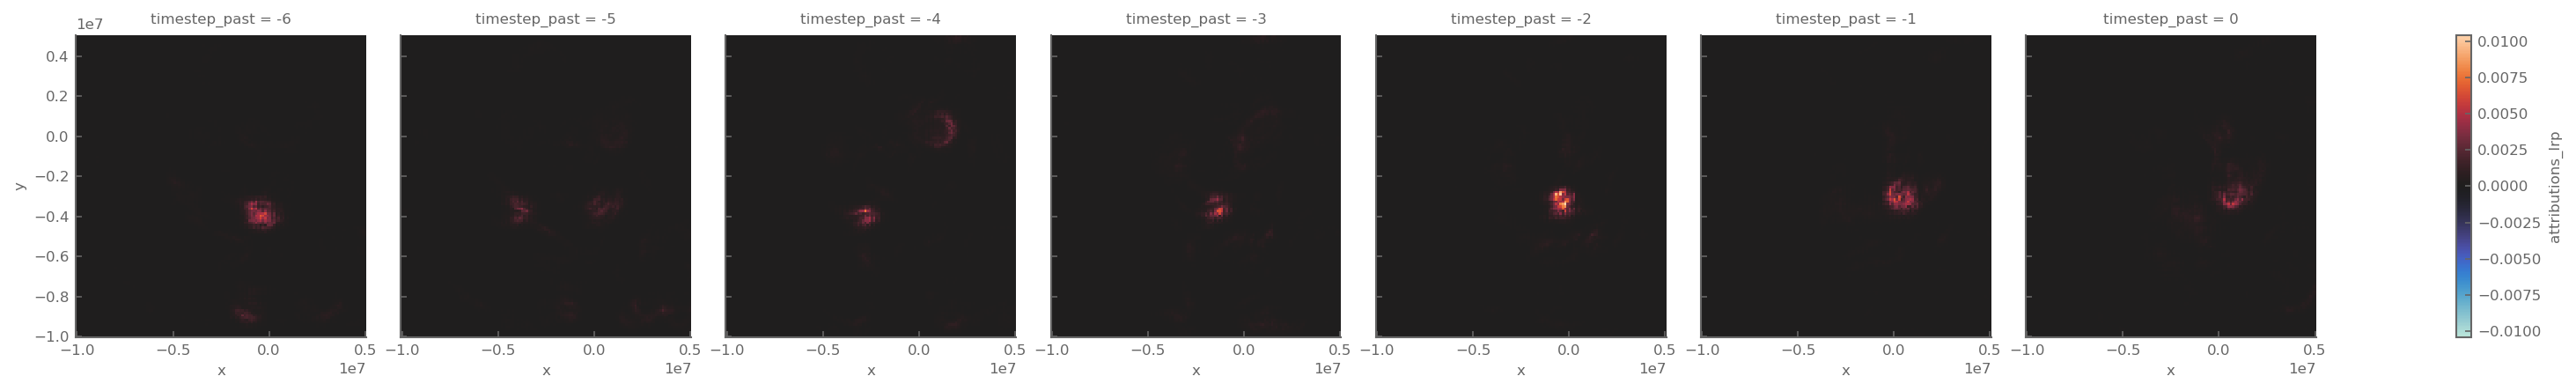

In [4]:
lrp_normed.sel(time_of_event='2016-08-09').plot(col='timestep_past', cmap='icefire')

## Compute aggregation with Moran's I


In [4]:
from esda.moran import Moran
from libpysal.weights import KNN, DistanceBand


times = ds_attrs.time_of_event.sel(time_of_event=slice('1979', '2024')).values

data = ds_attrs.sel(time_of_event='2016-08-09').sel(timestep_past=0).lrp_normed

X = data.to_dataframe().lrp_normed.reset_index().x.values
Y = data.to_dataframe().lrp_normed.reset_index().y.values
coords = np.column_stack([X, Y])
w = KNN.from_array(coords, k=4)  # or k=8

results = []

for time_of_event in tqdm(times):
    for timestep_past in range(-6,1):
        data_ = ds_attrs.sel(time_of_event=time_of_event).sel(timestep_past=timestep_past).lrp_normed
        numbers = data_.values.flatten()
        mi = Moran(numbers,w)
        results.append([time_of_event, timestep_past, mi.I, mi.p_sim])


ds = pd.DataFrame(results, columns = ['time_of_event','timestep_past','Moran_I','p_value']).set_index(['time_of_event','timestep_past']).to_xarray()
ds.to_netcdf(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_moranI_lrp_normed_v2.nc')

  0%|          | 0/840 [00:00<?, ?it/s]

# Cyclones stuff

## Load cyclone data

In [5]:
all_df_dailys = []
import glob
files = glob.glob('/Data/gfi/share/Reanalyses/ERA-5/detected_features/cyclone_tracks_melbourne/*.pos.nc')
files = [f for f in files if f.endswith('.nc')]
proj_stereo = CRS(f"+proj=stere +lat_0=90 +lat_ts=70 +lon_0=0 +x_0=0 +y_0=0 +ellps=WGS84 +units=m")
transformer = Transformer.from_crs("EPSG:4326", proj_stereo, always_xy=True)
for file in tqdm(files):
    with xr.open_dataset(file) as ds:
        df_ = ds[['track_id', 'lon','lat','msl','date']].to_dataframe()
        df_['date'] = pd.to_datetime(df_.date.dt.date)
        df_daily = df_.groupby(['date','track_id']).agg({'msl':'min','lon':'mean','lat':'mean'}).reset_index()   
        x,y = transformer.transform(df_daily['lon'].values, df_daily['lat'].values)
        df_daily['x'] = x
        df_daily['y'] = y
        all_df_dailys.append(df_daily)
        del df_
daily_cycs = pd.concat(all_df_dailys)
daily_cycs = daily_cycs.loc[(daily_cycs.x > -1e7)&(daily_cycs.x < .5e7)&(daily_cycs.y > -1e7)&(daily_cycs.y < .5e7)]
daily_cycs = daily_cycs.set_index('date').sort_index()
daily_cycs['track_id']=daily_cycs['track_id'].astype(int)#.astype(float)
daily_cycs['key'] = daily_cycs.index.strftime("%Y-%m-%d") + ' '+daily_cycs.track_id.astype(str)


cyclones_gdf = gpd.GeoDataFrame(
    daily_cycs.reset_index(),
    geometry=gpd.points_from_xy(daily_cycs["x"], daily_cycs["y"]),
    crs=proj  # adjust if your cyclones are in another CRS
).set_index('date')




  0%|          | 0/552 [00:00<?, ?it/s]

In [5]:
# cyclones_gdf = gpd.read_file('/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/all_cyclones.geojson')

## Define cyclone regions

In [5]:
space = np.array(['                     ' for k in cyclones_gdf.index])
space[((cyclones_gdf.lat>30)&(cyclones_gdf.lon<40)&(cyclones_gdf.lon>-20)).values] = 'Atlantic North East'
space[((cyclones_gdf.lat>30)&(cyclones_gdf.lon<-20)&(cyclones_gdf.lon>-100)).values] = 'Atlantic North West'
space[((cyclones_gdf.lat<60)&((cyclones_gdf.lon<-100)|(cyclones_gdf.lon>120))).values] = 'Pacific'
space[((cyclones_gdf.lat>60)&((cyclones_gdf.lon<-100)|(cyclones_gdf.lon>120))).values] = 'Arctic Pacific'
space[((cyclones_gdf.lat>60)&(cyclones_gdf.lon>40)&(cyclones_gdf.lon<120)).values] = 'Arctic Eurasia'
space[((cyclones_gdf.lat<60)&(cyclones_gdf.lon>40)&(cyclones_gdf.lon<120)).values] = 'Eurasia'

space[((cyclones_gdf.lat<30)&((cyclones_gdf.lon>-100)&(cyclones_gdf.lon<60))).values] = 'Tropical Atlantic'

cyclones_gdf['cyclone_region'] = space



In [ ]:
space = np.array(['                     ' for k in cyclones_gdf.index])
space[((cyclones_gdf.lat>30)&(cyclones_gdf.lon<-80)&(cyclones_gdf.lon>-120)).values] = 'North America'
space[((cyclones_gdf.lat>30)&(cyclones_gdf.lon<-45)&(cyclones_gdf.lon>-80)).values] = 'West Atlantic'
space[((cyclones_gdf.lat>30)&(cyclones_gdf.lon<-10)&(cyclones_gdf.lon>-45)).values] = 'East Atlantic'

space[((cyclones_gdf.lat>50)&(cyclones_gdf.lat<80)&(cyclones_gdf.lon>-10)&(cyclones_gdf.lon<40)).values] = 'Norway'
space[((cyclones_gdf.lat<50)&(cyclones_gdf.lat>30)&(cyclones_gdf.lon>-10)&(cyclones_gdf.lon<40)).values] = 'Europe'
space[((cyclones_gdf.lat>80)&(cyclones_gdf.lon>-10)&(cyclones_gdf.lon<40)).values] = 'Arctic Eurasia'
space[((cyclones_gdf.lat>60)&(cyclones_gdf.lon>40)&(cyclones_gdf.lon<120)).values] = 'Arctic Eurasia'
space[((cyclones_gdf.lat<60)&((cyclones_gdf.lon<-120)|(cyclones_gdf.lon>120))).values] = 'Pacific'
space[((cyclones_gdf.lat>60)&((cyclones_gdf.lon<-120)|(cyclones_gdf.lon>120))).values] = 'Arctic Pacific'
space[((cyclones_gdf.lat<60)&(cyclones_gdf.lon>40)&(cyclones_gdf.lon<120)).values] = 'Eurasia'
space[((cyclones_gdf.lat<30)&((cyclones_gdf.lon>-100)&(cyclones_gdf.lon<60))).values] = 'Tropical Atlantic'# 

# space[((cyclones_gdf.lat>55)&(cyclones_gdf.lon<-10)&(cyclones_gdf.lon>-45)).values] = 'North East Atlantic'

# space[((cyclones_gdf.lat>30)&(cyclones_gdf.lon<40)&(cyclones_gdf.lon>-20)).values] = 'Atlantic North East'
# space[((cyclones_gdf.lat>30)&(cyclones_gdf.lon<-20)&(cyclones_gdf.lon>-100)).values] = 'Atlantic North West'
# space[((cyclones_gdf.lat<60)&((cyclones_gdf.lon<-100)|(cyclones_gdf.lon>120))).values] = 'Pacific'
# space[((cyclones_gdf.lat>60)&((cyclones_gdf.lon<-100)|(cyclones_gdf.lon>120))).values] = 'Arctic Pacific'
# space[((cyclones_gdf.lat>60)&(cyclones_gdf.lon>40)&(cyclones_gdf.lon<120)).values] = 'Arctic Eurasia'
# space[((cyclones_gdf.lat<60)&(cyclones_gdf.lon>40)&(cyclones_gdf.lon<120)).values] = 'Eurasia'

# space[((cyclones_gdf.lat<30)&((cyclones_gdf.lon>-100)&(cyclones_gdf.lon<60))).values] = 'Tropical Atlantic'

cyclones_gdf['cyclone_region'] = space

cyclones_gdf.to_file(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/all_cyclones.geojson', driver='GeoJSON')


In [ ]:
# space = np.array(['                     ' for k in gdf_out.index])
# space[((gdf_out.cyclone_lat>30)&(gdf_out.cyclone_lon<-80)&(gdf_out.cyclone_lon>-120)).values] = 'North America'
# space[((gdf_out.cyclone_lat>30)&(gdf_out.cyclone_lon<-45)&(gdf_out.cyclone_lon>-80)).values] = 'West Atlantic'
# space[((gdf_out.cyclone_lat>30)&(gdf_out.cyclone_lon<-10)&(gdf_out.cyclone_lon>-45)).values] = 'East Atlantic'

# space[((gdf_out.cyclone_lat>50)&(gdf_out.cyclone_lat<80)&(gdf_out.cyclone_lon>-10)&(gdf_out.cyclone_lon<40)).values] = 'Norway'
# space[((gdf_out.cyclone_lat<50)&(gdf_out.cyclone_lat>30)&(gdf_out.cyclone_lon>-10)&(gdf_out.cyclone_lon<40)).values] = 'Europe'
# space[((gdf_out.cyclone_lat>80)&(gdf_out.cyclone_lon>-10)&(gdf_out.cyclone_lon<40)).values] = 'Arctic Eurasia'
# space[((gdf_out.cyclone_lat>60)&(gdf_out.cyclone_lon>40)&(gdf_out.cyclone_lon<120)).values] = 'Arctic Eurasia'
# space[((gdf_out.cyclone_lat<60)&((gdf_out.cyclone_lon<-120)|(gdf_out.cyclone_lon>120))).values] = 'Pacific'
# space[((gdf_out.cyclone_lat>60)&((gdf_out.cyclone_lon<-120)|(gdf_out.cyclone_lon>120))).values] = 'Arctic Pacific'
# space[((gdf_out.cyclone_lat<60)&(gdf_out.cyclone_lon>40)&(gdf_out.cyclone_lon<120)).values] = 'Eurasia'
# space[((gdf_out.cyclone_lat<30)&((gdf_out.cyclone_lon>-100)&(gdf_out.cyclone_lon<60))).values] = 'Tropical Atlantic'# 

# # space[((gdf_out.cyclone_lat>55)&(gdf_out.cyclone_lon<-10)&(gdf_out.cyclone_lon>-45)).values] = 'North East Atlantic'

# # space[((gdf_out.cyclone_lat>30)&(gdf_out.cyclone_lon<40)&(gdf_out.cyclone_lon>-20)).values] = 'Atlantic North East'
# # space[((gdf_out.cyclone_lat>30)&(gdf_out.cyclone_lon<-20)&(gdf_out.cyclone_lon>-100)).values] = 'Atlantic North West'
# # space[((gdf_out.cyclone_lat<60)&((gdf_out.cyclone_lon<-100)|(gdf_out.cyclone_lon>120))).values] = 'Pacific'
# # space[((gdf_out.cyclone_lat>60)&((gdf_out.cyclone_lon<-100)|(gdf_out.cyclone_lon>120))).values] = 'Arctic Pacific'
# # space[((gdf_out.cyclone_lat>60)&(gdf_out.cyclone_lon>40)&(gdf_out.cyclone_lon<120)).values] = 'Arctic Eurasia'
# # space[((gdf_out.cyclone_lat<60)&(gdf_out.cyclone_lon>40)&(gdf_out.cyclone_lon<120)).values] = 'Eurasia'

# # space[((gdf_out.cyclone_lat<30)&((gdf_out.cyclone_lon>-100)&(gdf_out.cyclone_lon<60))).values] = 'Tropical Atlantic'

# gdf_out['cyclone_region'] = space

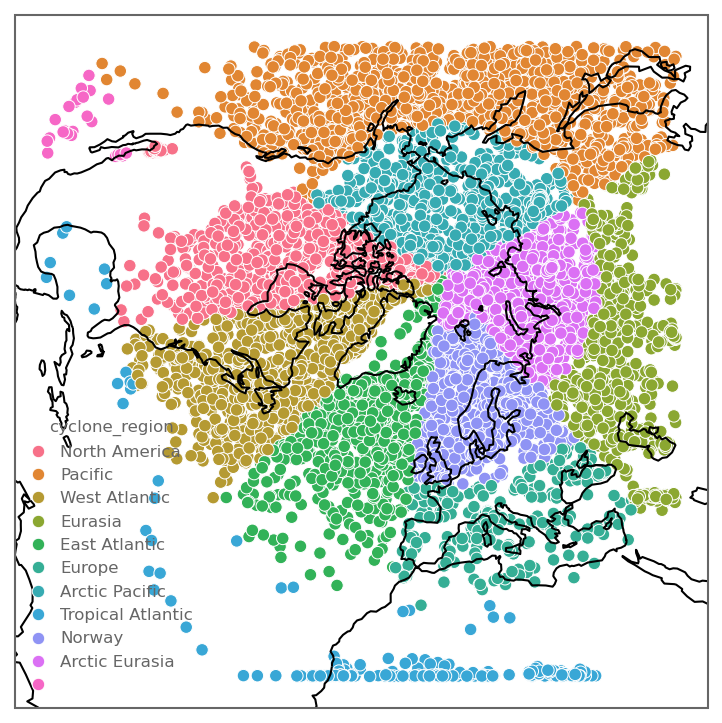

In [13]:
fig, ax =plt.subplots(subplot_kw=dict(projection=proj), figsize=(6,6))
# daily_cycs = pd.concat(all_df_dailys)

# cyclones_gdf.loc['2000'].plot.scatter(x='x',y='y', ax=ax, transform=proj)
# cyclones_gdf.loc['2000'].plot.scatter(x='lon',y='lat', ax=ax, transform=ccrs.PlateCarree())


sns.scatterplot(cyclones_gdf.loc['2000'], x='x', y='y', hue='cyclone_region', transform=proj)
ax.coastlines()

# ax.set_extent((-1e7,5e6,-1e7,5e6), crs=proj)

In [ ]:
all_trajs = []
cycs_nor = cyclones_gdf.query("cyclone_region=='Norway'")
for key in tqdm(cycs_nor.key):
    date, track_id = key.split(' ')
    # date = pd.to_datetime(date)
    track_id = int(track_id)
    df_ = cyclones_gdf.query('track_id==@track_id').loc[:date][[ 'track_id','cyclone_region']]
    df_.index = np.arange(-df_.index.size+1,1)
    all_trajs.append(df_)


<Axes: xlabel='timestep_past'>

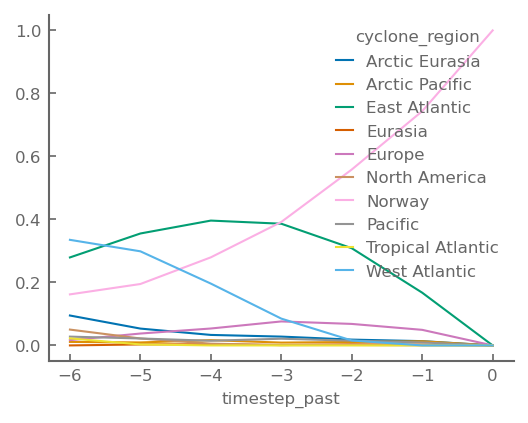

In [85]:
trajs = pd.concat(all_trajs).reset_index()
trajs.columns = ['timestep_past','track_id','cyclone_region']

df_ = trajs.groupby(['timestep_past','cyclone_region']).track_id.count().unstack().fillna(0)
# (_/_.sum(axis=0)).plot()
(df_.T/df_.T.sum()).T.iloc[-7:].plot()

In [107]:
df_gdf = gdf_out.groupby(['timestep_past','cyclone_region','time_of_event']).geometry.count().unstack().fillna(0)
df_gdf= (df_gdf>0).sum(axis=1)
# df_blobs


<Axes: xlabel='timestep_past'>

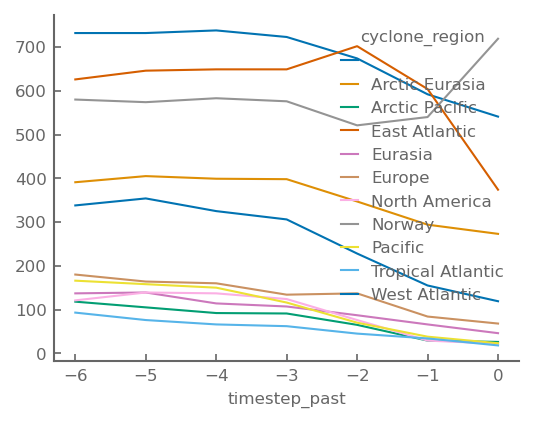

In [108]:
df_gdf.unstack().plot()

<GeoAxes: xlabel='x', ylabel='y'>

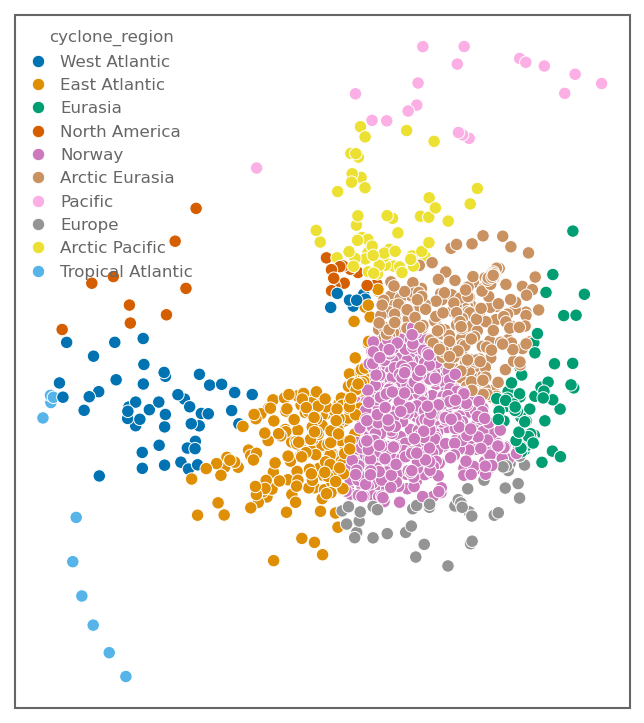

In [22]:
fig, ax =plt.subplots(subplot_kw=dict(projection=proj), figsize=(6,6))

cycs_nor= cyclones_gdf.loc[cyclones_gdf.track_id.isin(cyclones_gdf.query("cyclone_region=='Norway'").track_id)]
sns.scatterplot(cycs_nor.loc['2000'], x='x', y='y', hue='cyclone_region', transform=proj)

In [49]:
# cyclones_gdf.to_file(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/all_cyclones.geojson', driver='GeoJSON')
cyclones_gdf

,track_id,msl,lon,lat,x,y,key,geometry,cyclone_region
date,,,,,,,,,
1979-01-01,0,100487.303602,-76.048833,45.989150,-4.859531e+06,-1.207219e+06,1979-01-01 0,POINT (-4859530.961 -1207218.836),West Atlantic
1979-01-01,101,97338.043428,122.049854,74.149758,1.464296e+06,9.167662e+05,1979-01-01 101,POINT (1464295.962 916766.247),
1979-01-01,67,98855.651712,22.982749,46.559554,1.927227e+06,-4.544065e+06,1979-01-01 67,POINT (1927226.73 -4544065.058),Europe
1979-01-01,63,98734.763447,12.065410,44.373426,1.089235e+06,-5.095837e+06,1979-01-01 63,POINT (1089235.315 -5095836.517),Europe
1979-01-01,22,100754.987498,73.433667,48.961326,4.445745e+06,-1.322490e+06,1979-01-01 22,POINT (4445744.614 -1322490.065),
...,...,...,...,...,...,...,...,...,...
2024-12-30,955856,100503.970350,-102.183367,57.591066,-3.522528e+06,7.605272e+05,2024-12-30 955856,POINT (-3522528.207 760527.226),North America
2024-12-30,955852,101709.656783,6.671551,19.660674,1.011669e+06,-8.648989e+06,2024-12-30 955852,POINT (1011669.113 -8648988.538),
2024-12-30,955944,96591.911384,24.654133,71.221191,8.559414e+05,-1.864881e+06,2024-12-30 955944,POINT (855941.38 -1864881.024),Norway


## Define processing functions

In [6]:
def segments_from_attribution_grid(data, abs_threshold = 0.001, rolling=3):
    data_rolling = data.rolling(x=rolling,y=rolling,center=True).mean().fillna(0)
    data_rolling = data_rolling.where(np.abs(data_rolling)>abs_threshold,0)
    img = data_rolling.values
    img = img/img.max()
    segments_fz, num_features = scipy.ndimage.label(img, structure=[[1,1,1],[1,1,1],[1,1,1],])
    segments = xr.DataArray(segments_fz, dims=data.dims, coords=data.coords)
    attribution_per_segment = data.groupby(segments).sum().to_series().rename('attributions')
    return segments, attribution_per_segment

def get_gdf_from_segment_grid(segments):
    x = segments.x.values
    y = segments.y.values
    labels = segments.values
    dx = float(np.mean(np.diff(x))) 
    dy = float(np.mean(np.diff(y))) 
    x0 = x.min() - dx / 2.0
    y0 = y.min() - dy / 2.0  
    transform = Affine.translation(x0, y0) * Affine.scale(dx, dy)
    geoms = []
    vals = []
    for geom, value in features.shapes(labels, transform=transform):
        if value == 0:
            continue
        geoms.append(shape(geom))
        vals.append(value)
    gdf_segments = gpd.GeoDataFrame(
        {"label": vals},
        geometry=geoms,
        crs="EPSG:3413"   # or "EPSG:3995" or your custom proj string
    )
    gdf_segments= gdf_segments.set_index('label') 
    gdf_segments=gdf_segments.reset_index().dissolve(by='label')
    return gdf_segments

def get_segments_gdf_for_day(time_of_event, timestep_past, segments_kwargs=dict()):
    data = ds_attrs.sel(time_of_event=time_of_event,timestep_past=timestep_past).lrp_normed
    segments, attribution_per_segment = segments_from_attribution_grid(data, **segments_kwargs)
    gdf_segments = get_gdf_from_segment_grid(segments)
    gdf_segments['attributions'] = attribution_per_segment
    return segments, gdf_segments

def get_cyclones_for_day(time_of_event, timestep_past):
    time = pd.to_datetime(time_of_event) + pd.Timedelta(f'{timestep_past}D')
    cyclones_gdf_day = cyclones_gdf.loc[time.strftime("%Y-%m-%d")]
    return cyclones_gdf_day.set_index('track_id')

def get_intersection(gdf_segments, cyclones_gdf_day, buffer=500_000):
    intersects = cyclones_gdf_day.geometry.buffer(buffer).apply(lambda g: gdf_segments.intersection(g).loc[gdf_segments.intersects(g)]).dropna(how='all')
    intersects = intersects.stack().reset_index()
    intersects.columns = ['track_id','segment_label','geometry']
    intersects = gpd.GeoDataFrame(intersects, geometry='geometry', crs=gdf_segments.crs)
    return intersects

def attribution_segments(gdf_segments, cyclones_gdf_day):
    intersects500= get_intersection(gdf_segments, cyclones_gdf_day, buffer=500_000)
    intersects500['area'] = intersects500.geometry.area
    gdf_segments['cyclones'] = intersects500.set_index('track_id').groupby('segment_label').area.idxmax()
    return gdf_segments

## Get blobs and cyclones together

In [7]:
times = ds_attrs.time_of_event.sel(time_of_event=slice(None, '2024')).values
all_gdf_segments = []
for time_of_event in tqdm(times):
    for timestep_past in range(-6,1):
        segments, gdf_segments = get_segments_gdf_for_day(time_of_event, timestep_past, segments_kwargs=dict(abs_threshold = 0.0005, rolling=5))
        cyclones_gdf_day = get_cyclones_for_day(time_of_event, timestep_past)
        gdf_segments = attribution_segments(gdf_segments, cyclones_gdf_day)
        gdf_segments['time_of_event'] = time_of_event
        gdf_segments['timestep_past'] = timestep_past

        all_gdf_segments.append(gdf_segments)
df_ = pd.concat(all_gdf_segments)
df_['segment_size'] = df_.area/1_000_000
df_['is_cyclone'] = df_.cyclones.notnull()
df_['date'] = df_.time_of_event + pd.Timedelta('1D')*df_.timestep_past
categories = np.array(['                     ' for k in df_.index])
categories[((df_.segment_size<0.1e7)).values] = 'small blob'
categories[((np.abs(df_.attributions)<.05)&(df_.segment_size>0.1e7)).values] = 'large neutral'
categories[((df_.attributions<-.05)&(df_.segment_size>0.1e7)).values] = 'large negative'
categories[((df_.attributions>.05)&(df_.segment_size>0.1e7)).values] = 'large positive'
df_['category'] = categories

  0%|          | 0/840 [00:00<?, ?it/s]

In [8]:
df_blob_cycs = pd.DataFrame(df_.groupby(['cyclones', 'date','time_of_event']).agg(dict(attributions='sum',
                                                                    #    time_of_event='first',
                                                                       timestep_past='first',
                                                                       segment_size='sum')))
gdf_blob_cycs = gpd.GeoDataFrame(df_blob_cycs, geometry= df_.dissolve(by=['cyclones', 'date','time_of_event']).geometry)
categories = np.array(['                     ' for k in df_blob_cycs.index])
categories[((gdf_blob_cycs.segment_size<0.1e7)).values] = 'small blob'
categories[((np.abs(gdf_blob_cycs.attributions)<.1)&(gdf_blob_cycs.segment_size>0.1e7)).values] = 'large neutral'
categories[((gdf_blob_cycs.attributions<-.1)&(gdf_blob_cycs.segment_size>0.1e7)).values] = 'large negative'
categories[((gdf_blob_cycs.attributions>.1)&(gdf_blob_cycs.segment_size>0.1e7)).values] = 'large positive'
gdf_blob_cycs['blob_category'] = categories
gdf_blob_cycs['key'] = (gdf_blob_cycs.reset_index().date.dt.strftime("%Y-%m-%d") + ' '+gdf_blob_cycs.reset_index().cyclones.astype(int).astype(str)).values

daily_cycs_for_blobs = daily_cycs.reset_index().set_index('key').loc[gdf_blob_cycs.key]
gdf_blob_cycs[['cyclone_msl','cyclone_lon','cyclone_lat','cyclone_x','cyclone_y']] = daily_cycs_for_blobs[['msl','lon','lat','x','y']].values


# space = np.array(['                     ' for k in df_blob_cycs.index])
# space[((gdf_blob_cycs.cyclone_lat>30)&(gdf_blob_cycs.cyclone_lon<40)&(gdf_blob_cycs.cyclone_lon>-20)).values] = 'Atlantic North East'
# space[((gdf_blob_cycs.cyclone_lat>30)&(gdf_blob_cycs.cyclone_lon<-20)&(gdf_blob_cycs.cyclone_lon>-100)).values] = 'Atlantic North West'
# space[((gdf_blob_cycs.cyclone_lat<60)&((gdf_blob_cycs.cyclone_lon<-100)|(gdf_blob_cycs.cyclone_lon>120))).values] = 'Pacific'
# space[((gdf_blob_cycs.cyclone_lat>60)&((gdf_blob_cycs.cyclone_lon<-100)|(gdf_blob_cycs.cyclone_lon>120))).values] = 'Arctic Pacific'
# space[((gdf_blob_cycs.cyclone_lat>60)&(gdf_blob_cycs.cyclone_lon>40)&(gdf_blob_cycs.cyclone_lon<120)).values] = 'Arctic Eurasia'
# space[((gdf_blob_cycs.cyclone_lat<60)&(gdf_blob_cycs.cyclone_lon>40)&(gdf_blob_cycs.cyclone_lon<120)).values] = 'Eurasia'

# space[((gdf_blob_cycs.cyclone_lat<30)&((gdf_blob_cycs.cyclone_lon>-100)&(gdf_blob_cycs.cyclone_lon<60))).values] = 'Tropical Atlantic'

# gdf_blob_cycs['cyclone_region'] = space
gdf_blob_cycs = gdf_blob_cycs.reset_index().rename(columns=dict(cyclones='cyclone_track_id', date='cyclone_date',segment_size='blob_area', attributions='blob_attributions'))
gdf_no_cyclones = df_.query("~is_cyclone").fillna("No cyclone").rename(columns=dict(cyclones='cyclone_track_id', date='cyclone_date',segment_size='blob_area', attributions='blob_attributions', category='blob_category')).reset_index().drop('label', axis=1)
gdf_out = pd.concat([gdf_blob_cycs, gdf_no_cyclones])
gdf_out['is_cyclone'] = gdf_out.cyclone_track_id != 'No cyclone'
gdf_out.to_file(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_cyclones_data.geojson', driver='GeoJSON')


In [110]:
gdf_out

,cyclone_track_id,cyclone_date,time_of_event,blob_attributions,timestep_past,blob_area,geometry,blob_category,key,cyclone_msl,cyclone_lon,cyclone_lat,cyclone_x,cyclone_y,cyclone_region,is_cyclone
0,0.0,1979-01-02,1979-01-07,0.057921,-5,8.788518e+05,"POLYGON ((-4507874.016 -2972440.945, -4507874....",small blob,1979-01-02 0,100748.992025,-63.887996,50.383825,-4.008538e+06,-1.964804e+06,West Atlantic,True
1,5.0,1979-01-01,1979-01-07,0.022079,-6,3.348007e+05,"POLYGON ((-2145669.291 -2972440.945, -2145669....",small blob,1979-01-01 5,100420.881110,-37.015497,62.698079,-1.813646e+06,-2.405435e+06,East Atlantic,True
2,9.0,1979-01-01,1979-01-07,0.009593,-6,1.813504e+05,"POLYGON ((-964566.929 -2854330.709, -964566.92...",small blob,1979-01-01 9,100280.337114,-16.353258,66.703640,-7.201089e+05,-2.454110e+06,East Atlantic,True
3,9.0,1979-01-02,1979-01-07,0.046147,-5,5.859012e+05,"POLYGON ((-728346.457 -2736220.472, -728346.45...",small blob,1979-01-02 9,99926.784449,-10.505497,67.502952,-4.499136e+05,-2.426217e+06,East Atlantic,True
4,9.0,1979-01-03,1979-01-07,0.019342,-4,2.790006e+05,"MULTIPOLYGON (((-19685.039 -2500000, 216535.43...",small blob,1979-01-03 9,99545.643639,-7.205030,67.149896,-3.144668e+05,-2.487504e+06,Norway,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13725,No cyclone,2024-12-26,2024-12-29,0.029103,-3,4.882510e+05,"POLYGON ((334645.669 -3681102.362, 334645.669 ...",small blob,NaN,NaN,NaN,NaN,NaN,NaN,,False
13726,No cyclone,2024-12-26,2024-12-29,-0.094954,-3,1.157852e+06,"POLYGON ((-19685.039 -2972440.945, -19685.039 ...",large negative,NaN,NaN,NaN,NaN,NaN,NaN,,False
13727,No cyclone,2024-12-26,2024-12-29,0.077470,-3,8.509517e+05,"POLYGON ((-846456.693 -1791338.583, -846456.69...",small blob,NaN,NaN,NaN,NaN,NaN,NaN,,False
13728,No cyclone,2024-12-27,2024-12-29,-0.014401,-2,2.929506e+05,"POLYGON ((570866.142 -2854330.709, 570866.142 ...",small blob,NaN,NaN,NaN,NaN,NaN,NaN,,False


In [48]:
gdf_out.groupby(['time_of_event','timestep_past','cyclone_region']).geometry.count().rename('count')

time_of_event  timestep_past  cyclone_region     
1979-01-07     -6             Arctic Pacific         1
                              Atlantic North East    3
                              Atlantic North West    1
                              Eurasia                1
               -5             Arctic Eurasia         2
                                                    ..
1990-03-24     -2             Atlantic North East    2
                              Tropical Atlantic      1
               -1             Atlantic North East    1
                              Atlantic North West    1
                0             Atlantic North East    1
Name: count, Length: 3319, dtype: int64

In [42]:
daily_cycs.reset_index().set_index('key')

,date,track_id,msl,lon,lat,x,y
key,,,,,,,
1979-01-01 0,1979-01-01,0,100487.303602,-76.048833,45.989150,-4.859531e+06,-1.207219e+06
1979-01-01 101,1979-01-01,101,97338.043428,122.049854,74.149758,1.464296e+06,9.167662e+05
1979-01-01 67,1979-01-01,67,98855.651712,22.982749,46.559554,1.927227e+06,-4.544065e+06
1979-01-01 63,1979-01-01,63,98734.763447,12.065410,44.373426,1.089235e+06,-5.095837e+06
1979-01-01 22,1979-01-01,22,100754.987498,73.433667,48.961326,4.445745e+06,-1.322490e+06
...,...,...,...,...,...,...,...
2024-12-30 955856,2024-12-30,955856,100503.970350,-102.183367,57.591066,-3.522528e+06,7.605272e+05
2024-12-30 955852,2024-12-30,955852,101709.656783,6.671551,19.660674,1.011669e+06,-8.648989e+06
2024-12-30 955944,2024-12-30,955944,96591.911384,24.654133,71.221191,8.559414e+05,-1.864881e+06


In [36]:
gdf_blob_cycs

attributions  timestep_past  segment_size  \
cyclones date       time_of_event                                              
0.0      1979-01-02 1979-01-07         0.057921             -5  8.788518e+05   
5.0      1979-01-01 1979-01-07         0.022079             -6  3.348007e+05   
9.0      1979-01-01 1979-01-07         0.009593             -6  1.813504e+05   
         1979-01-02 1979-01-07         0.046147             -5  5.859012e+05   
         1979-01-03 1979-01-07         0.019342             -4  2.790006e+05   
...                                         ...            ...           ...   
229100.0 1990-03-22 1990-03-24        -0.031381             -2  5.859012e+05   
229107.0 1990-03-23 1990-03-24        -0.019938             -1  3.487507e+05   
229184.0 1990-03-23 1990-03-23         0.765003              0  5.538161e+06   
                    1990-03-24         0.769151             -1  5.580011e+06   
         1990-03-24 1990-03-24         0.765517              0  4.575609e+06   

                                                                            geometry  \
cyclones date       time_of_event                                                      
0.0      1979-01-02 1979-01-07     POLYGON ((-4507874.016 -2972440.945, -4507874....   
5.0      1979-01-01 1979-01-07     POLYGON ((-2145669.291 -2972440.945, -2145669....   
9.0      1979-01-01 1979-01-07     POLYGON ((-964566.929 -2854330.709, -964566.92...   
         1979-01-02 1979-01-07     POLYGON ((-728346.457 -2736220.472, -728346.45...   
         1979-01-03 1979-01-07     MULTIPOLYGON (((-19685.039 -2500000, 216535.43...   
...                                                                              ...   
229100.0 1990-03-22 1990-03-24     POLYGON ((1751968.504 -3090551.181, 1751968.50...   
229107.0 1990-03-23 1990-03-24     POLYGON ((-3562992.126 -2381889.764, -3562992....   
229184.0 1990-03-23 1990-03-23     POLYGON ((-1200787.402 -4153543.307, -1200787....   
                    1990-03-24     POLYGON ((-1437007.874 -4271653.543, -1437007....   
         1990-03-24 1990-03-24     POLYGON ((452755.906 -4035433.071, 452755.906 ...   

                                    blob_category                  key  
cyclones date       time_of_event                                       
0.0      1979-01-02 1979-01-07         small blob       1979-01-02 0.0  
5.0      1979-01-01 1979-01-07         small blob       1979-01-01 5.0  
9.0      1979-01-01 1979-01-07         small blob       1979-01-01 9.0  
         1979-01-02 1979-01-07         small blob       1979-01-02 9.0  
         1979-01-03 1979-01-07         small blob       1979-01-03 9.0  
...                                           ...                  ...  
229100.0 1990-03-22 1990-03-24         small blob  1990-03-22 229100.0  
229107.0 1990-03-23 1990-03-24         small blob  1990-03-23 229107.0  
229184.0 1990-03-23 1990-03-23     large positive  1990-03-23 229184.0  
                    1990-03-24     large positive  1990-03-23 229184.0  
         1990-03-24 1990-03-24     large positive  1990-03-24 229184.0  

[4528 rows x 6 columns]

# Compute model skills

In [46]:
gdf_blob_cycs.reset_index()#.iloc[:10].plot()

,cyclones,date,time_of_event,attributions,timestep_past,segment_size,geometry,blob_category,key,cyclone_msl,cyclone_lon,cyclone_lat,cyclone_x,cyclone_y,cyclone_region
0,0.0,1979-01-02,1979-01-07,0.133534,-5,1.605536e+06,"POLYGON ((-4764705.882 -2411764.706, -4764705....",large positive,1979-01-02 0.0,100748.992025,-63.887996,50.383825,-4.008538e+06,-1.964804e+06,Atlantic North West
1,1.0,1979-01-02,1979-01-07,-0.157968,-5,2.435986e+06,"POLYGON ((-3235294.118 3235294.118, -3235294.1...",large negative,1979-01-02 1.0,98249.611824,-147.176294,43.191290,-2.906224e+06,4.505482e+06,Pacific
2,63.0,1979-01-01,1979-01-07,0.283721,-6,4.152249e+06,"POLYGON ((-294117.647 -5823529.412, -294117.64...",large positive,1979-01-01 63.0,98734.763447,12.065410,44.373426,1.089235e+06,-5.095837e+06,Atlantic North East
3,63.0,1979-01-02,1979-01-07,-0.019889,-5,4.152249e+05,"POLYGON ((1235294.118 -5000000, 1235294.118 -4...",small blob,1979-01-02 63.0,99217.934317,17.402162,41.479960,1.669372e+06,-5.326267e+06,Atlantic North East
4,101.0,1979-01-02,1979-01-07,0.036689,-5,7.889273e+05,"POLYGON ((1705882.353 411764.706, 1705882.353 ...",small blob,1979-01-02 101.0,97681.687267,119.179105,75.706298,1.358678e+06,7.586896e+05,Arctic Eurasia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20267,955745.0,2024-12-27,2024-12-29,0.032762,-2,5.259516e+05,"POLYGON ((882352.941 -1470588.235, 882352.941 ...",small blob,2024-12-27 955745.0,96923.116597,46.186797,76.116053,1.090423e+06,-1.046160e+06,Arctic Eurasia
20268,955824.0,2024-12-26,2024-12-29,0.208707,-3,2.795848e+06,"POLYGON ((-1823529.412 -3470588.235, -1823529....",large positive,2024-12-26 955824.0,98384.445043,-36.773051,64.343516,-1.691066e+06,-2.262712e+06,Atlantic North West
20269,955824.0,2024-12-27,2024-12-29,0.560398,-2,4.013841e+06,"POLYGON ((-1941176.471 -3705882.353, -1941176....",large positive,2024-12-27 955824.0,97797.009193,-28.665021,65.675232,-1.282562e+06,-2.346047e+06,Atlantic North West
20270,955824.0,2024-12-28,2024-12-29,0.669679,-1,6.339100e+06,"POLYGON ((-1823529.412 -4882352.941, -1823529....",large positive,2024-12-28 955824.0,98269.606412,-9.323234,70.095391,-3.527292e+05,-2.148525e+06,Atlantic North East


In [29]:
gdf_blob_cycs = gpd.GeoDataFrame(df_blob_cycs, geometry= df_.dissolve(by=['cyclones', 'date','time_of_event']).geometry)

In [28]:
gdf

attributions  timestep_past  segment_size  \
cyclones date       time_of_event                                              
0.0      1979-01-02 1979-01-07         0.133534             -5  1.605536e+06   
1.0      1979-01-02 1979-01-07        -0.157968             -5  2.435986e+06   
63.0     1979-01-01 1979-01-07         0.283721             -6  4.152249e+06   
         1979-01-02 1979-01-07        -0.019889             -5  4.152249e+05   
101.0    1979-01-02 1979-01-07         0.036689             -5  7.889273e+05   
...                                         ...            ...           ...   
955745.0 2024-12-27 2024-12-29         0.032762             -2  5.259516e+05   
955824.0 2024-12-26 2024-12-29         0.208707             -3  2.795848e+06   
         2024-12-27 2024-12-29         0.560398             -2  4.013841e+06   
         2024-12-28 2024-12-29         0.669679             -1  6.339100e+06   
955944.0 2024-12-29 2024-12-29         0.788672              0  7.487889e+06   

                                                                            geometry  
cyclones date       time_of_event                                                     
0.0      1979-01-02 1979-01-07     POLYGON ((-4764705.882 -2411764.706, -4764705....  
1.0      1979-01-02 1979-01-07     POLYGON ((-3235294.118 3235294.118, -3235294.1...  
63.0     1979-01-01 1979-01-07     POLYGON ((-294117.647 -5823529.412, -294117.64...  
         1979-01-02 1979-01-07     POLYGON ((1235294.118 -5000000, 1235294.118 -4...  
101.0    1979-01-02 1979-01-07     POLYGON ((1705882.353 411764.706, 1705882.353 ...  
...                                                                              ...  
955745.0 2024-12-27 2024-12-29     POLYGON ((882352.941 -1470588.235, 882352.941 ...  
955824.0 2024-12-26 2024-12-29     POLYGON ((-1823529.412 -3470588.235, -1823529....  
         2024-12-27 2024-12-29     POLYGON ((-1941176.471 -3705882.353, -1941176....  
         2024-12-28 2024-12-29     POLYGON ((-1823529.412 -4882352.941, -1823529....  
955944.0 2024-12-29 2024-12-29     POLYGON ((-1470588.235 -5000000, -1470588.235 ...  

[20272 rows x 4 columns]

/tmp/ipykernel_2052969/14549296.py:1: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df_.query("(cyclones==203952.0)  & (date=='1988-12-26')").plot()


<Axes: >

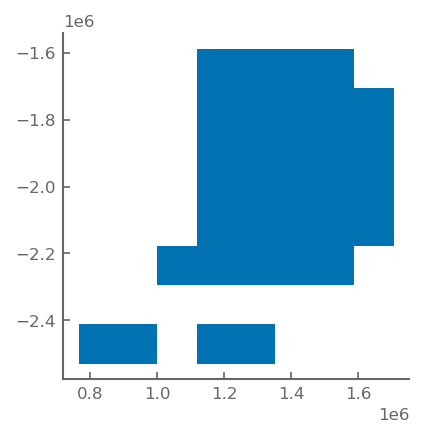

In [16]:
df_.query("(cyclones==203952.0)  & (date=='1988-12-26')").plot()

In [ ]:
df_blob_cycs = pd.DataFrame(df_.groupby(['cyclones', 'date','time_of_event']).agg(dict(attributions='sum',
                                                                    #    time_of_event='first',
                                                                       timestep_past='first',
                                                                       segment_size='sum')))
categories = np.array(['                     ' for k in df_blob_cycs.index])
categories[((df_blob_cycs.segment_size<0.1e7)).values] = 'small blob'
categories[((np.abs(df_blob_cycs.attributions)<.1)&(df_blob_cycs.segment_size>0.1e7)).values] = 'large neutral'
categories[((df_blob_cycs.attributions<-.1)&(df_blob_cycs.segment_size>0.1e7)).values] = 'large negative'
categories[((df_blob_cycs.attributions>.1)&(df_blob_cycs.segment_size>0.1e7)).values] = 'large positive'
df_blob_cycs['category'] = categories
df_blob_cycs['key'] = (df_blob_cycs.reset_index().date.dt.strftime("%Y-%m-%d") + ' '+df_blob_cycs.reset_index().cyclones.astype(str)).values

daily_cycs_for_blobs = daily_cycs.reset_index().set_index('key').loc[df_blob_cycs.key]
df_blob_cycs[['msl','lon','lat','x','y']] = daily_cycs_for_blobs[['msl','lon','lat','x','y']].values
# df_blob_cycs = pd.concat([daily_cycs.reset_index().set_index(['track_id','date']), df_blob_cycs.reset_index().rename(columns=dict(cyclones='track_id')).set_index(['track_id','date'])],axis=1)
# df_blob_cycs
# df_blob_cycs.groupby(['cyclones', 'date']).segment_size.sum()

In [134]:
df_['segment_size'] = df_.area/1_000_000
df_['is_cyclone'] = df_.cyclones.notnull()
df_['date'] = df_.time_of_event + pd.Timedelta('1D')*df_.timestep_past
categories = np.array(['                     ' for k in df_.index])
categories[((df_.segment_size<0.1e7)).values] = 'small blob'
categories[((np.abs(df_.attributions)<.05)&(df_.segment_size>0.1e7)).values] = 'large neutral'
categories[((df_.attributions<-.05)&(df_.segment_size>0.1e7)).values] = 'large negative'
categories[((df_.attributions>.05)&(df_.segment_size>0.1e7)).values] = 'large positive'
df_['category'] = categories

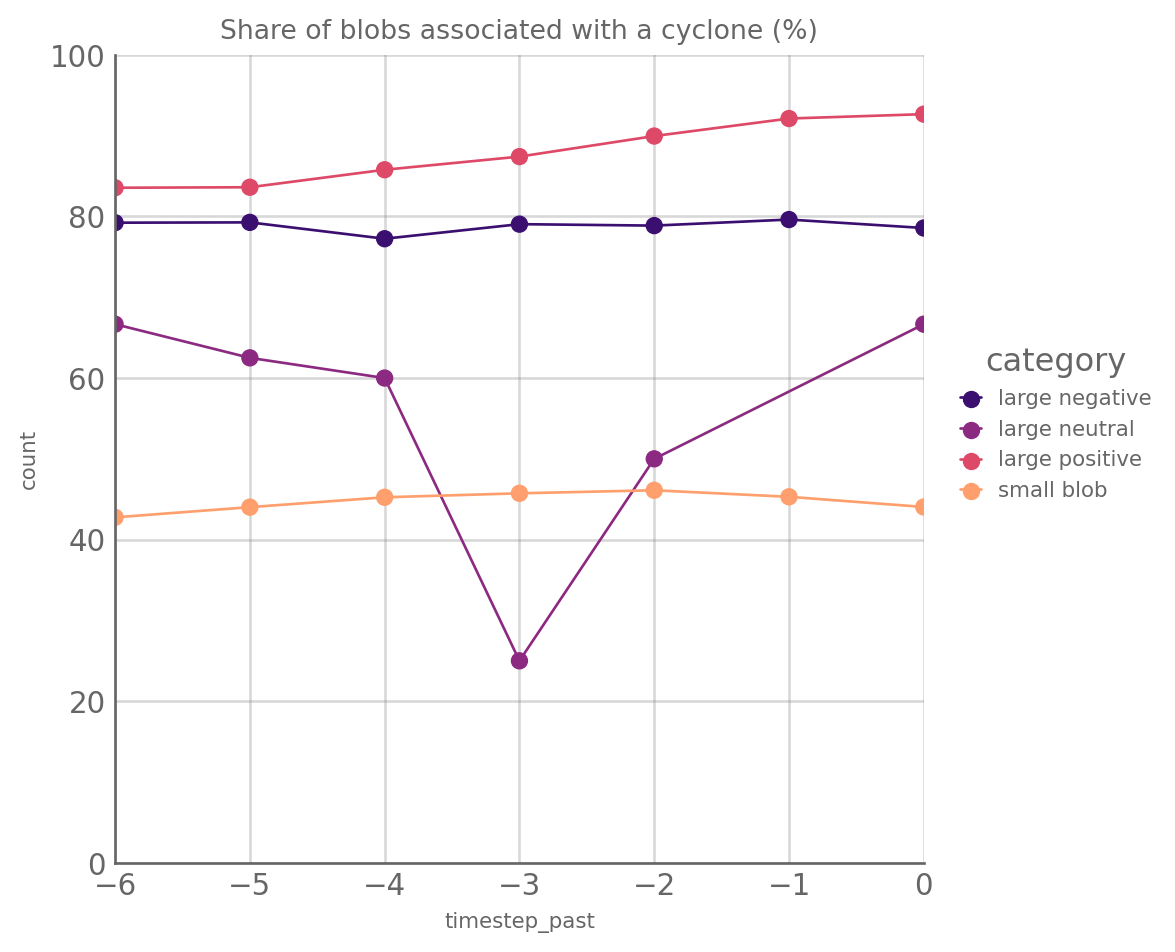

In [174]:
df_plot = (100*df_.query("is_cyclone").groupby(['timestep_past','category']).time_of_event.count().rename('count')/df_.groupby(['timestep_past','category']).time_of_event.count().rename('count')).reset_index()
(so.Plot(df_plot , x='timestep_past', color='category', y='count')
.add(so.Line(), )
.add(so.Dot(), )
 .label(title='Share of blobs associated with a cyclone (%)')
 .layout(size=(5,5))
 .limit(x=(-6,0), y=(0,100))
 .theme(plt.style.library["robin"])
 .scale(color = 'magma')
 .theme({'axes.grid':True, 'grid.color':'.5','grid.linestyle':'-', 'grid.alpha':.3})
)

/tmp/ipykernel_59320/1233076026.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df__ = df_.groupby(['timestep_past','time_of_event', ]).apply(lambda x:x.query("category=='large positive'").category.size).rename('large positive blob').reset_index()#.groupby(['timestep_past', 'category']).count().reset_index()


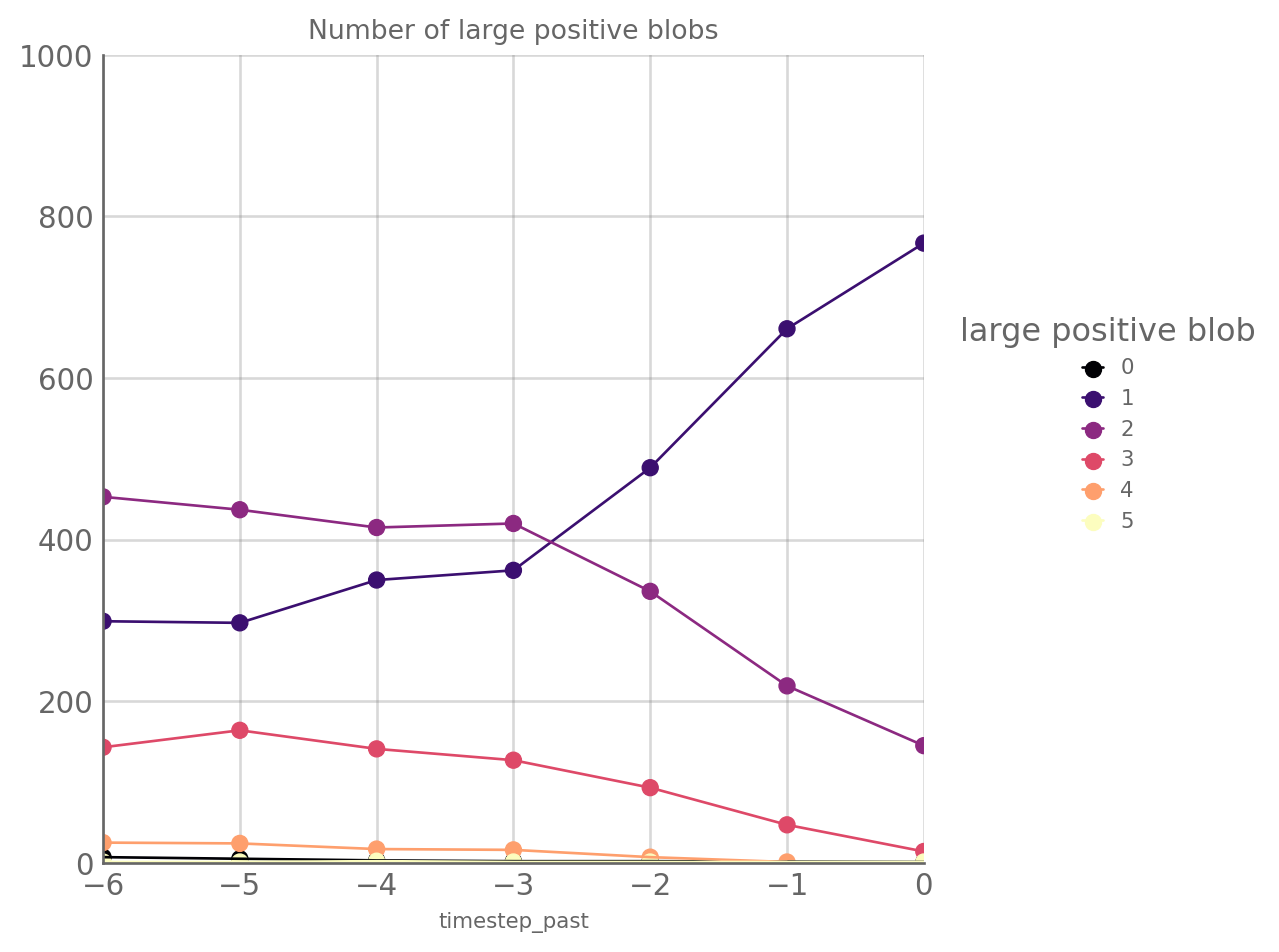

In [954]:
df__ = df_.groupby(['timestep_past','time_of_event', ]).apply(lambda x:x.query("category=='large positive'").category.size).rename('large positive blob').reset_index()#.groupby(['timestep_past', 'category']).count().reset_index()
(so.Plot(df__, x='timestep_past', color='large positive blob')
.add(so.Line(), so.Count())
.add(so.Dot(), so.Count())
 .label(title='Number of large positive blobs')
 .layout(size=(5,5))
 .limit(x=(-6,0), y=(0,1000))
 .theme(plt.style.library["robin"])
 .scale(color = 'magma')
 .theme({'axes.grid':True, 'grid.color':'.5','grid.linestyle':'-', 'grid.alpha':.3})
)
# df__

/tmp/ipykernel_59320/1602290768.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df__ = df_.groupby(['timestep_past','time_of_event', ]).apply(lambda x:x.query("category=='large positive'").cyclones.count()).rename('cyclone_count').reset_index()


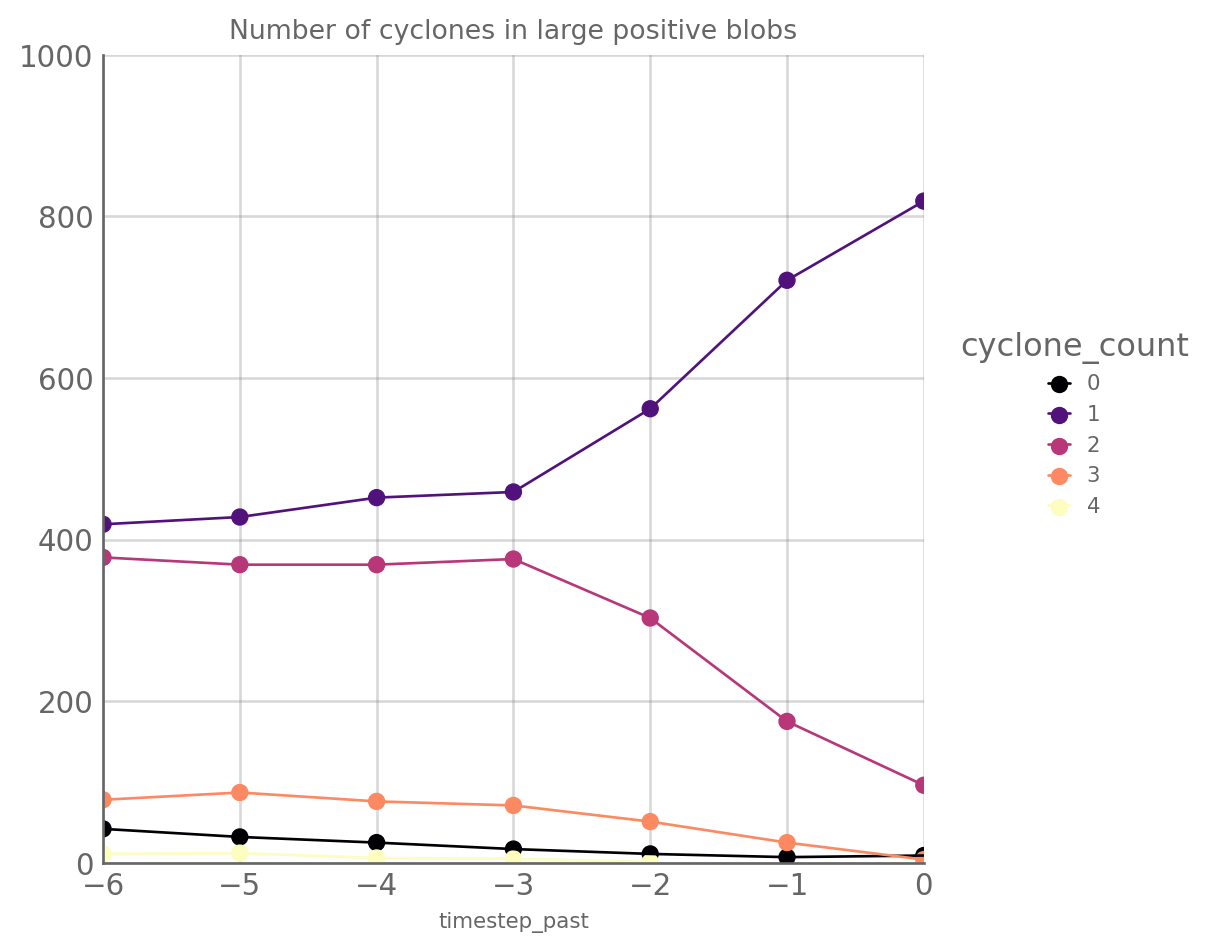

In [955]:
df__ = df_.groupby(['timestep_past','time_of_event', ]).apply(lambda x:x.query("category=='large positive'").cyclones.count()).rename('cyclone_count').reset_index()
(so.Plot(df__, x='timestep_past', color='cyclone_count')
.add(so.Line(), so.Count())
.add(so.Dot(), so.Count())
 .label(title='Number of cyclones in large positive blobs')

 .layout(size=(5,5))
  .limit(x=(-6,0), y=(0,1000))
  .theme(plt.style.library["robin"])
  .scale(color = 'magma')
 .theme({'axes.grid':True, 'grid.color':'.5','grid.linestyle':'-', 'grid.alpha':.3})
)

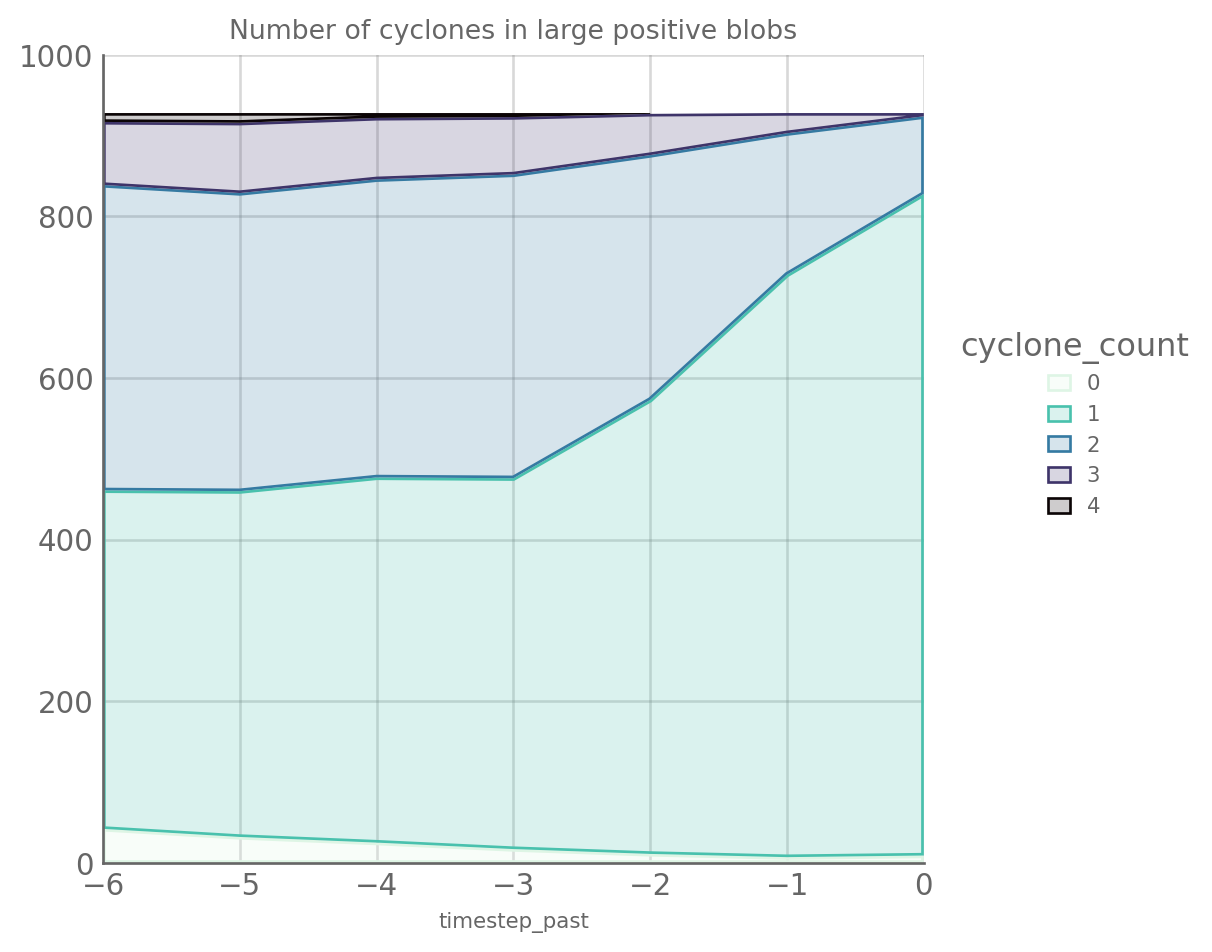

In [957]:
(so.Plot(df__, x='timestep_past', color='cyclone_count')
.add(so.Area(), so.Count(), so.Stack())
# .add(so.Dot(), so.Count())
 .label(title='Number of cyclones in large positive blobs')

 .layout(size=(5,5))
  .limit(x=(-6,0), y=(0,1000))
  .theme(plt.style.library["robin"])
  .scale(color = 'mako_r')
 .theme({'axes.grid':True, 'grid.color':'.5','grid.linestyle':'-', 'grid.alpha':.3})
)

/tmp/ipykernel_59320/3726925019.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df__ = df_.groupby(['timestep_past','time_of_event', 'is_cyclone']).apply(lambda x:x.query("category=='large positive'").category.size).rename('large positive blob').reset_index()#.groupby(['timestep_past', 'category']).count().reset_index()


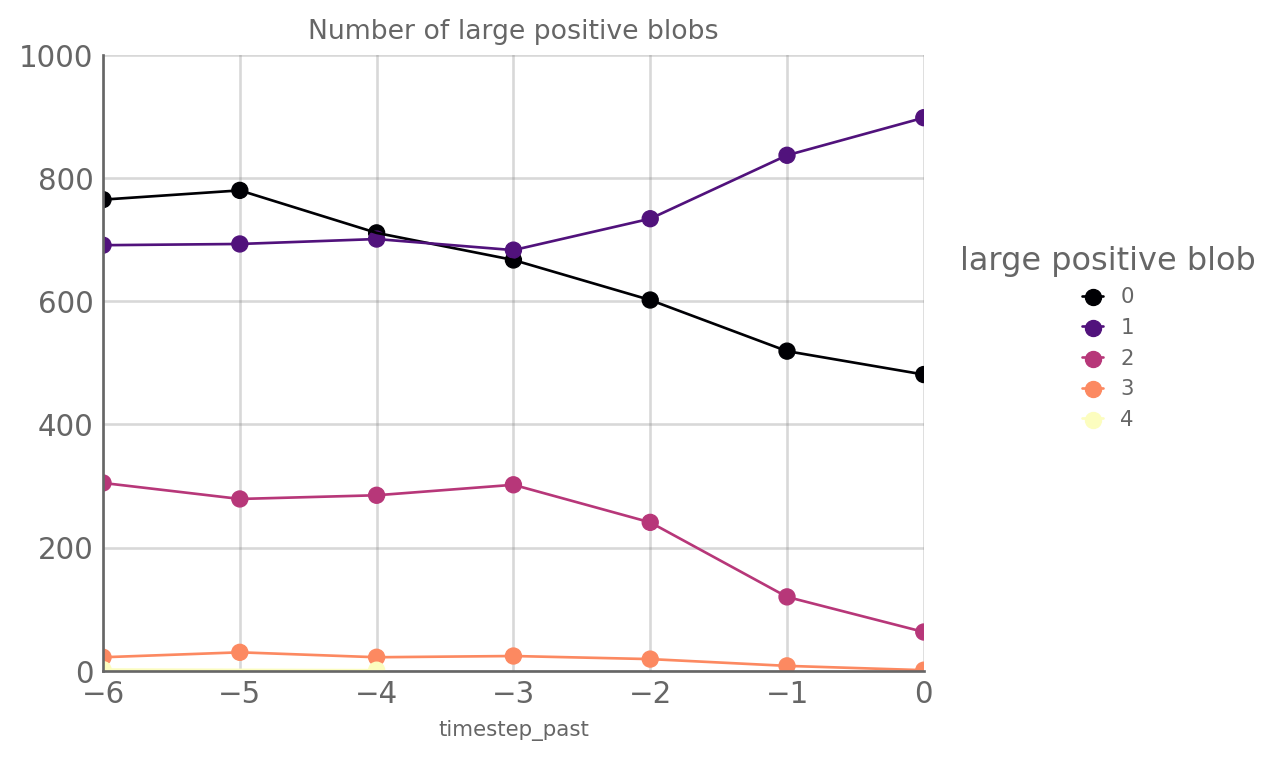

In [922]:
df__ = df_.groupby(['timestep_past','time_of_event', 'is_cyclone']).apply(lambda x:x.query("category=='large positive'").category.size).rename('large positive blob').reset_index()#.groupby(['timestep_past', 'category']).count().reset_index()
(so.Plot(df__, x='timestep_past', color='large positive blob')
.add(so.Line(), so.Count())
.add(so.Dot(), so.Count())
 .label(title='Number of large positive blobs')

 .layout(size=(5,5))
 .limit(x=(-6,0), y=(0,1000))
  .theme(plt.style.library["robin"])
  .scale(color = 'magma')
 .theme({'axes.grid':True, 'grid.color':'.5','grid.linestyle':'-', 'grid.alpha':.3})
)
# df__

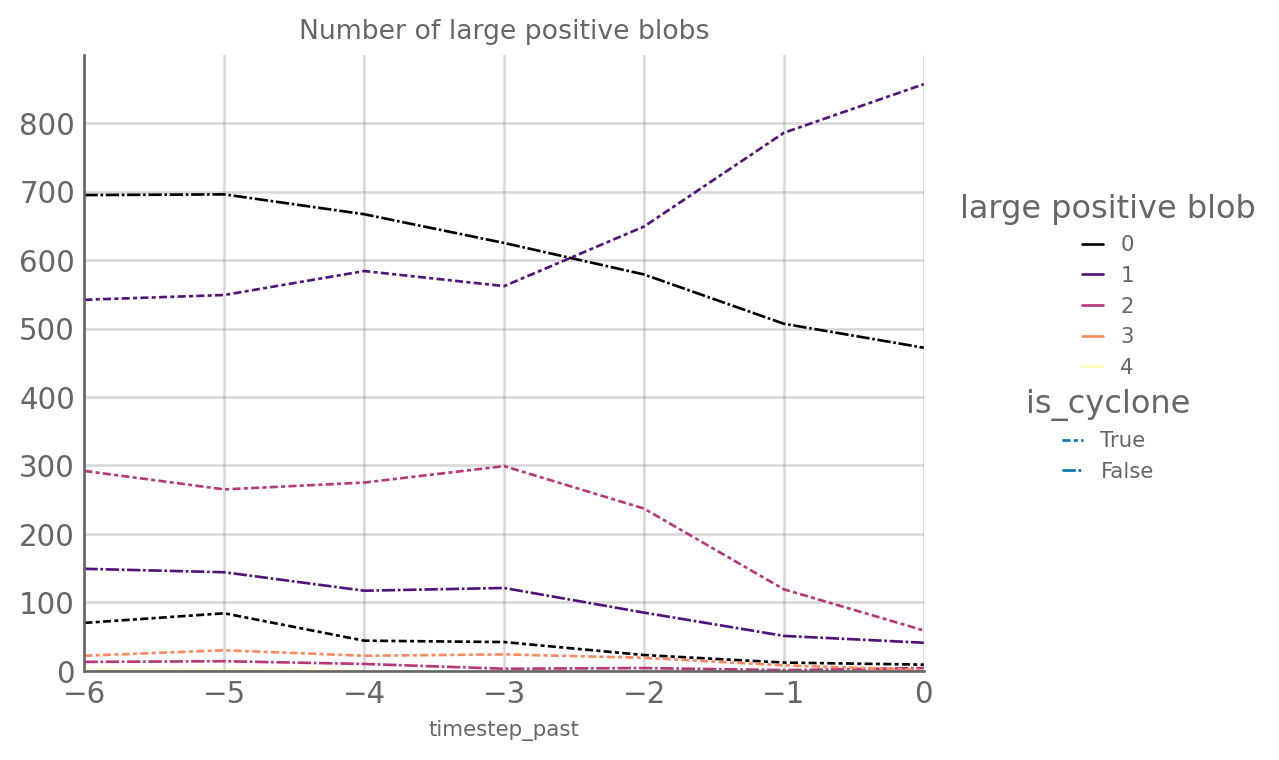

In [904]:
(so.Plot(df__, x='timestep_past', color='large positive blob', linestyle='is_cyclone')
.add(so.Line(), so.Count())
# .add(so.Dot(), so.Count())
 .label(title='Number of large positive blobs')

 .layout(size=(5,4))
 .limit(x=(-6,0), y=(0,None))
  .theme(plt.style.library["robin"])
  .scale(color = 'magma')
 .theme({'axes.grid':True, 'grid.color':'.5','grid.linestyle':'-', 'grid.alpha':.3})
)


In [628]:
df_['segment_size'] = df_.area/1_000_000
df_['is_cyclone'] = df_.cyclones.notnull()
df_['date'] = df_.time_of_event + pd.Timedelta('1D')*df_.timestep_past
categories = np.array(['                     ' for k in df_.index])
categories[((df_.segment_size<0.1e7)).values] = 'small blob'
categories[((np.abs(df_.attributions)<.1)&(df_.segment_size>0.1e7)).values] = 'large neutral'
categories[((df_.attributions<-.1)&(df_.segment_size>0.1e7)).values] = 'large negative'
categories[((df_.attributions>.1)&(df_.segment_size>0.1e7)).values] = 'large positive'
df_['category'] = categories

## Blobs distributions

KeyboardInterrupt: 

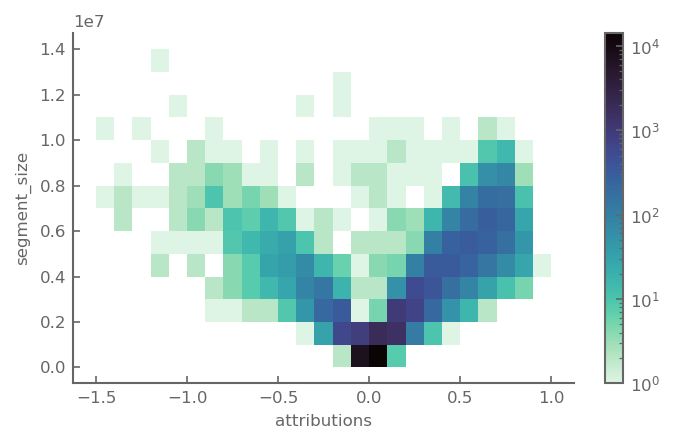

In [589]:
plot = sns.displot(df_, x = 'attributions', y ='segment_size', norm=LogNorm(), cmap='mako_r', vmin=None, vmax=None, 
                   bins=[np.arange(-1.5,1.1,.1), np.arange(0,1.5,.1)*1e7], 
                   cbar = True, aspect=1.6, height=3)
ax = plot.axes[0,0]
ax.set_xlim(-1.5,1)
ax.set_ylim(0,1.4e7)
ax.grid()

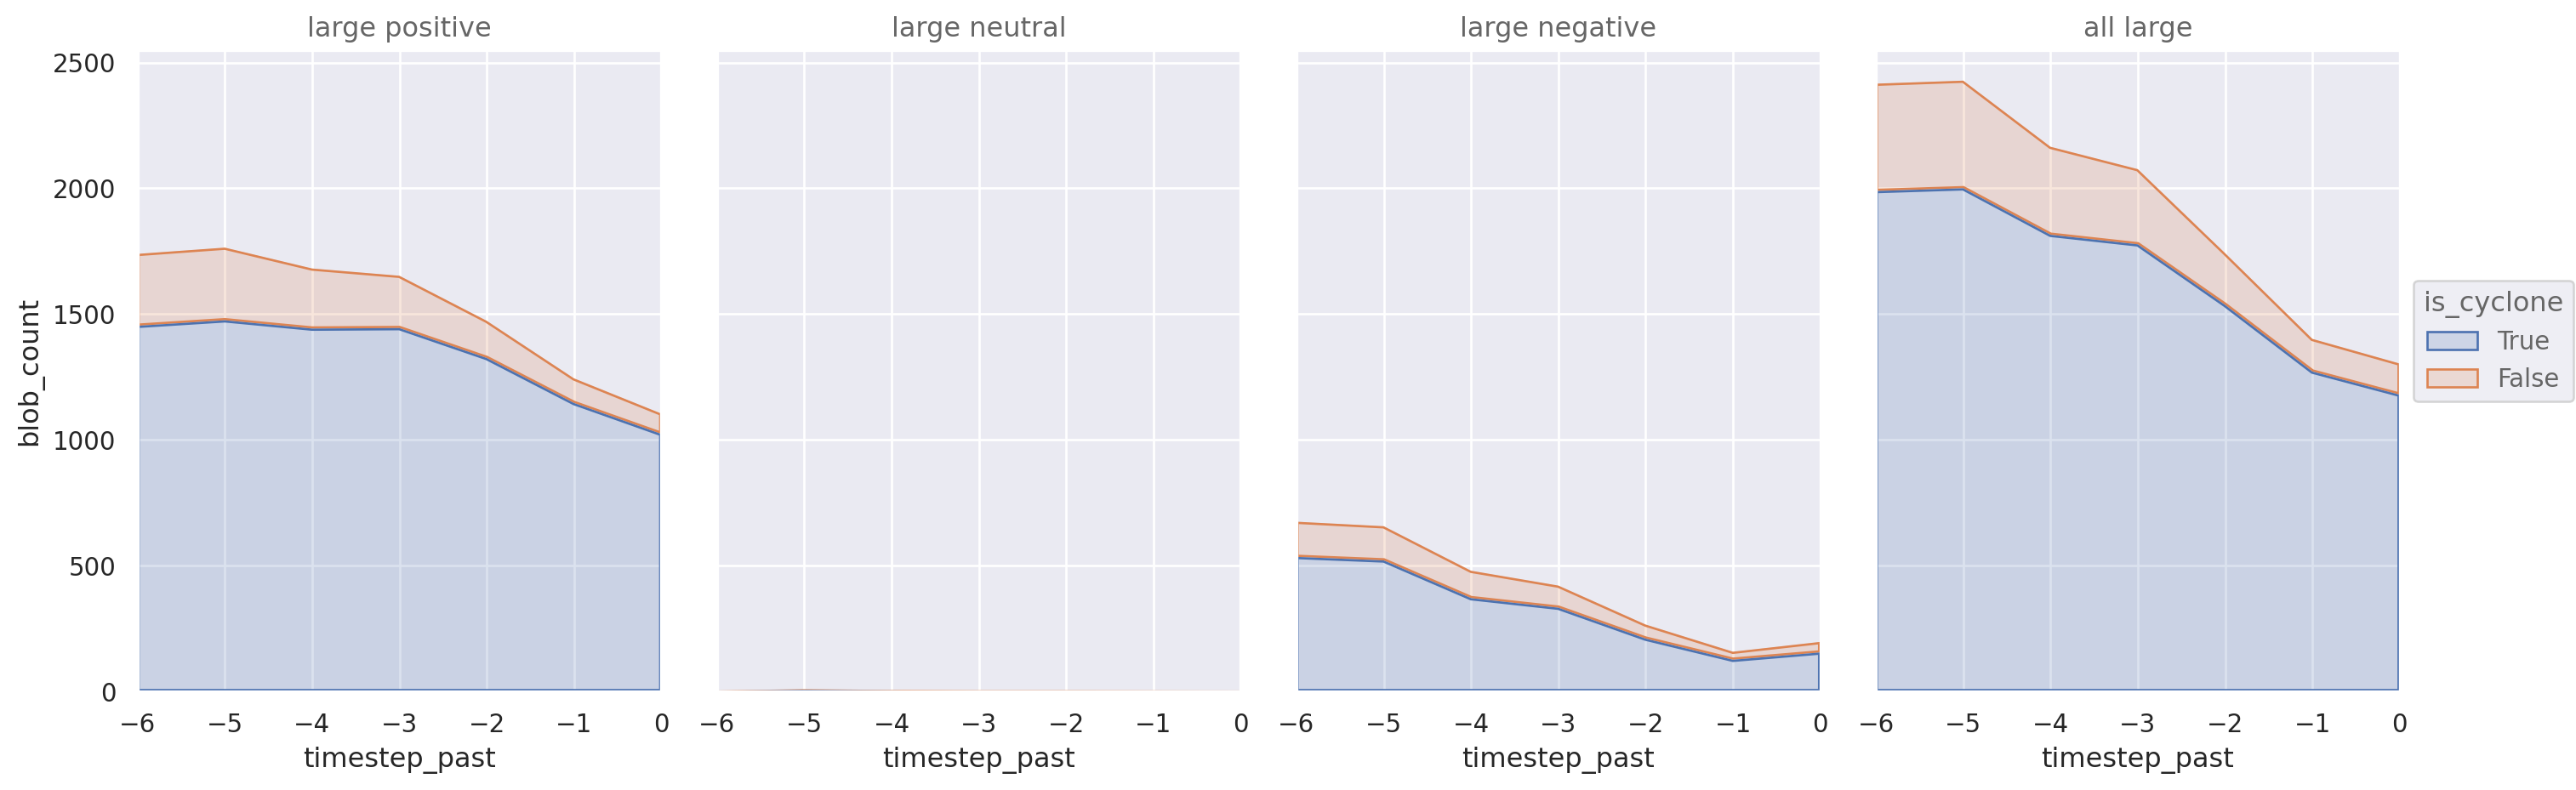

In [958]:
df_counts = df_.query("segment_size>.1e7").groupby(['category', 'is_cyclone','timestep_past']).geometry.count().rename('blob_count').reset_index()[::-1]
df_counts_all = df_.query("segment_size>.1e7").groupby([ 'is_cyclone','timestep_past']).geometry.count().rename('blob_count').reset_index()[::-1]
df_counts_all['category'] = 'all large'
df_counts = pd.concat([df_counts,df_counts_all])
df_counts
(so.Plot(df_counts, x='timestep_past', color='is_cyclone', y='blob_count')
 .add(so.Area(), so.Stack(), )
 .scale(col=so.Nominal(order=['large positive', 'large negative', 'large neutral', 'small blobs']))
#  .scale(stack=so.Nominal(order=[True, False]))
 .layout(size=(15,5))
 .facet(col='category')
#  .share(y=False)
 .limit(x=(-6,0), y=(0,None))
 
)


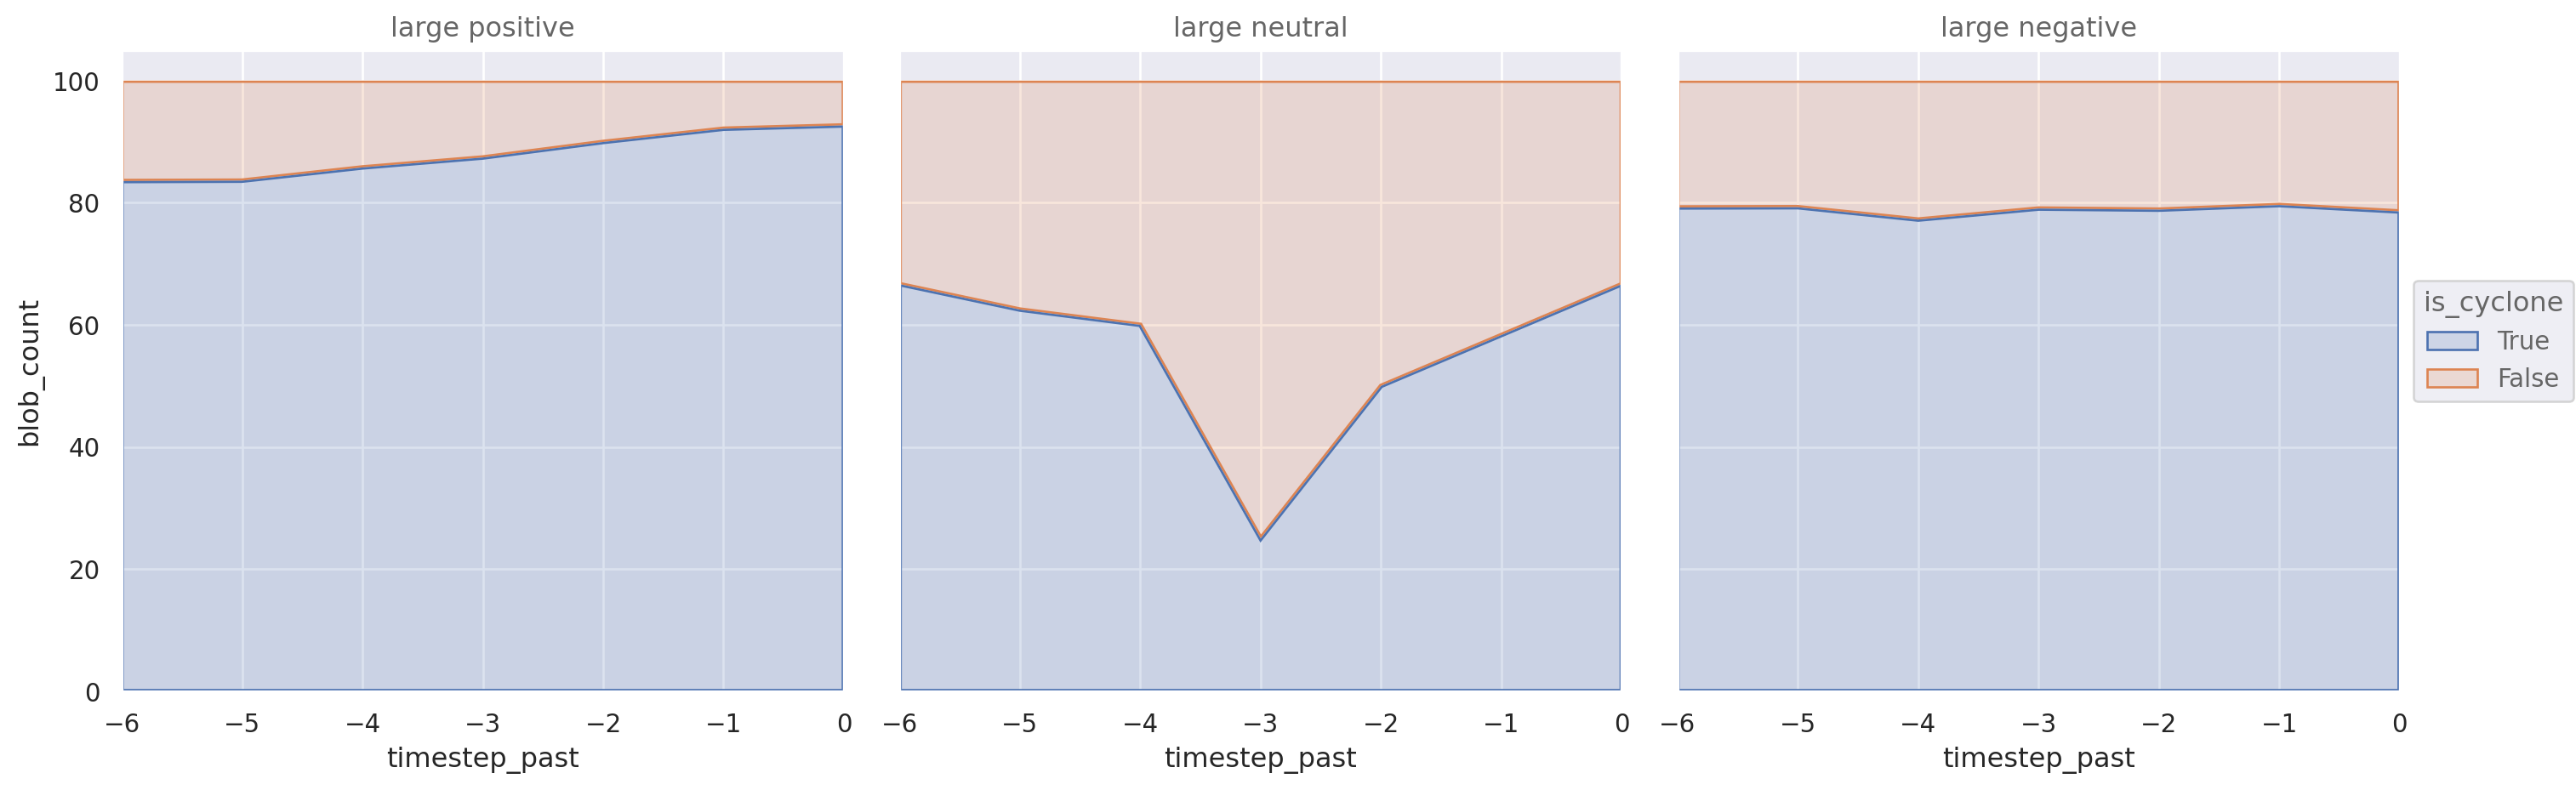

In [959]:
df_counts = df_.query("segment_size>.1e7").groupby(['category', 'is_cyclone','timestep_past']).geometry.count().rename('blob_count')
df_counts_all = df_.query("segment_size>.1e7").groupby(['category','timestep_past']).geometry.count().rename('blob_count')
# df_counts_all['category'] = 'all large'
df_counts=100*df_counts/df_counts_all
df_counts
(so.Plot(df_counts.reset_index()[::-1], x='timestep_past', color='is_cyclone', y='blob_count')
 .add(so.Area(), so.Stack(), )
 .scale(col=so.Nominal(order=['large positive', 'large negative', 'large neutral', 'small blobs']))
 .scale(stack=so.Nominal(order=[False, True]))
 .layout(size=(15,5))
 .facet(col='category')
#  .share(y=False)
 .limit(x=(-6,0), y=(0,None))
 
)


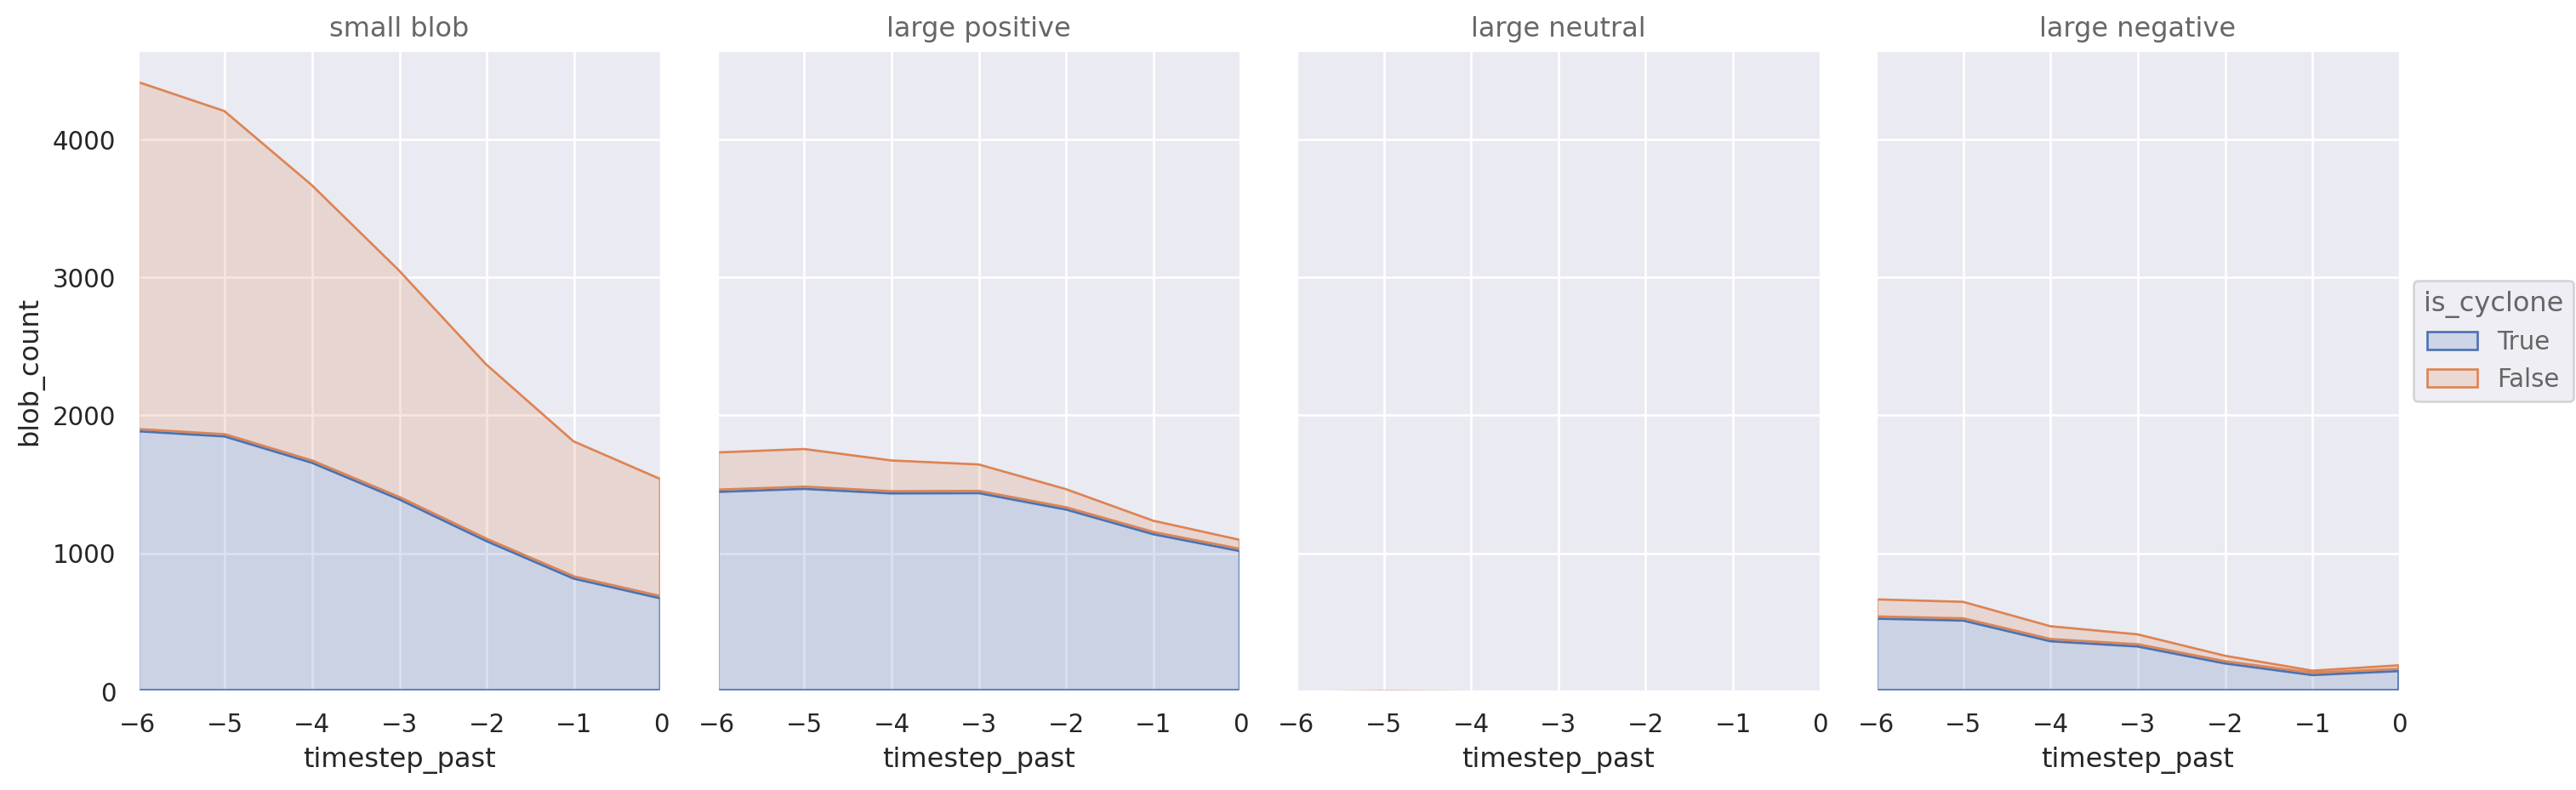

In [960]:
df__ = df_.groupby(['category', 'is_cyclone','timestep_past']).geometry.count().rename('blob_count').reset_index()[::-1]
# df__['category'] = ['Small negative']*2 + ['Large negative']*2 +['Small neutral']*2+['Large neutral']*2+['Small positive']*2+['Large positive']*2
(so.Plot(df__, x='timestep_past', color='is_cyclone', y='blob_count')
 .add(so.Area(), so.Stack(), )
 .scale(col=so.Nominal(order=['large positive', 'large negative', 'large neutral', 'small blobs']))
#  .scale(stack=so.Nominal(order=[True, False]))
 .layout(size=(15,5))
 .facet(col='category')
#  .share(y=False)
 .limit(x=(-6,0), y=(0,None))
 
)

# df__

/tmp/ipykernel_59320/2584833716.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_counts = df_.query("category!='small blob'").groupby([pd.cut(df_.query("category!='small blob'").attributions, np.arange(-1.5,1.1,.1)),'is_cyclone', 'timestep_past']).geometry.count().rename('blob_count').reset_index()[::-1]


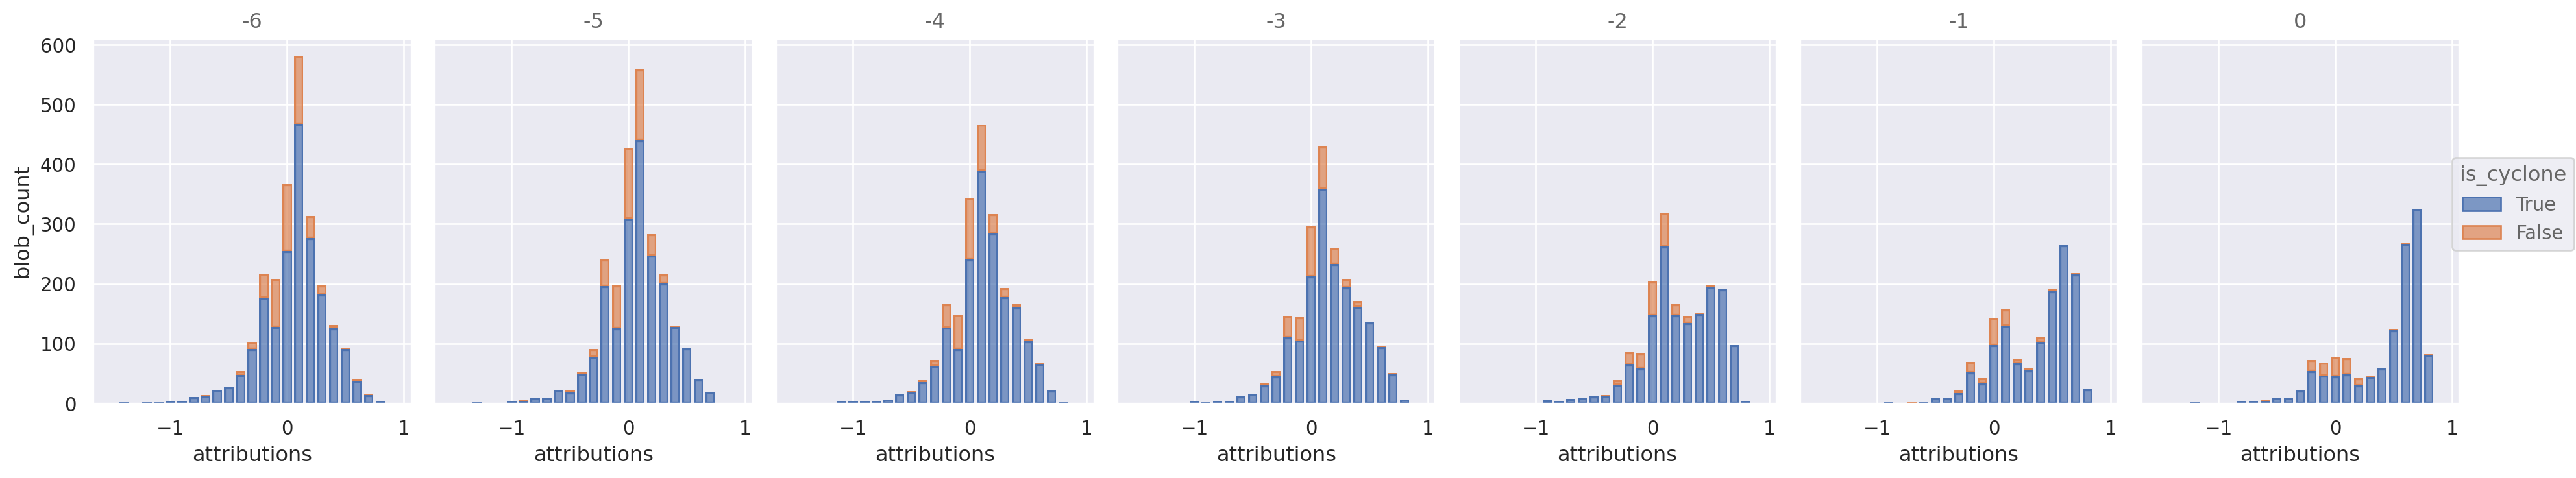

In [631]:
df_counts = df_.query("category!='small blob'").groupby([pd.cut(df_.query("category!='small blob'").attributions, np.arange(-1.5,1.1,.1)),'is_cyclone', 'timestep_past']).geometry.count().rename('blob_count').reset_index()[::-1]
df_counts['attributions'] = [k.left for k in df_counts.attributions]
(so.Plot(df_counts,color='is_cyclone',
         y='blob_count',
         x='attributions')
         .add(so.Bar(), so.Stack())
         .facet(col='timestep_past')
         .layout(size=(20,4))
 
 )

In [961]:
df_blob_cycs = pd.DataFrame(df_.groupby(['cyclones', 'date','time_of_event']).agg(dict(attributions='sum',
                                                                    #    time_of_event='first',
                                                                       timestep_past='first',
                                                                       segment_size='sum')))
categories = np.array(['                     ' for k in df_blob_cycs.index])
categories[((df_blob_cycs.segment_size<0.1e7)).values] = 'small blob'
categories[((np.abs(df_blob_cycs.attributions)<.1)&(df_blob_cycs.segment_size>0.1e7)).values] = 'large neutral'
categories[((df_blob_cycs.attributions<-.1)&(df_blob_cycs.segment_size>0.1e7)).values] = 'large negative'
categories[((df_blob_cycs.attributions>.1)&(df_blob_cycs.segment_size>0.1e7)).values] = 'large positive'
df_blob_cycs['category'] = categories
df_blob_cycs['key'] = (df_blob_cycs.reset_index().date.dt.strftime("%Y-%m-%d") + ' '+df_blob_cycs.reset_index().cyclones.astype(str)).values

daily_cycs_for_blobs = daily_cycs.reset_index().set_index('key').loc[df_blob_cycs.key]
df_blob_cycs[['msl','lon','lat','x','y']] = daily_cycs_for_blobs[['msl','lon','lat','x','y']].values
# df_blob_cycs = pd.concat([daily_cycs.reset_index().set_index(['track_id','date']), df_blob_cycs.reset_index().rename(columns=dict(cyclones='track_id')).set_index(['track_id','date'])],axis=1)
# df_blob_cycs
# df_blob_cycs.groupby(['cyclones', 'date']).segment_size.sum()

In [962]:

space = np.array(['                     ' for k in df_blob_cycs.index])
space[((df_blob_cycs.lat>30)&(df_blob_cycs.lon<40)&(df_blob_cycs.lon>-20)).values] = 'Atlantic North East'
space[((df_blob_cycs.lat>30)&(df_blob_cycs.lon<-20)&(df_blob_cycs.lon>-100)).values] = 'Atlantic North West'
space[((df_blob_cycs.lat<60)&((df_blob_cycs.lon<-100)|(df_blob_cycs.lon>120))).values] = 'Pacific'
space[((df_blob_cycs.lat>60)&((df_blob_cycs.lon<-100)|(df_blob_cycs.lon>120))).values] = 'Arctic Pacific'
space[((df_blob_cycs.lat>60)&(df_blob_cycs.lon>40)&(df_blob_cycs.lon<120)).values] = 'Arctic Eurasia'
space[((df_blob_cycs.lat<60)&(df_blob_cycs.lon>40)&(df_blob_cycs.lon<120)).values] = 'Eurasia'

space[((df_blob_cycs.lat<30)&((df_blob_cycs.lon>-100)&(df_blob_cycs.lon<60))).values] = 'Tropical Atlantic'

df_blob_cycs['region'] = space


In [963]:

# space = np.array(['                     ' for k in df_blob_cycs.index])
# space[((df_blob_cycs.lat>30)&(df_blob_cycs.lon<40)&(df_blob_cycs.lon>-10)).values] = 'Atlantic North East'
# space[((df_blob_cycs.lat>30)&(df_blob_cycs.lon<-10)&(df_blob_cycs.lon>-50)).values] = 'Atlantic North Center'
# space[((df_blob_cycs.lat>30)&(df_blob_cycs.lon<-40)&(df_blob_cycs.lon>-100)).values] = 'Atlantic North West'
# space[((df_blob_cycs.lat<60)&((df_blob_cycs.lon<-100)|(df_blob_cycs.lon>120))).values] = 'Pacific'
# space[((df_blob_cycs.lat>60)&((df_blob_cycs.lon<-100)|(df_blob_cycs.lon>120))).values] = 'Arctic Pacific'
# space[((df_blob_cycs.lat>60)&(df_blob_cycs.lon>40)&(df_blob_cycs.lon<120)).values] = 'Arctic Eurasia'
# space[((df_blob_cycs.lat<60)&(df_blob_cycs.lon>40)&(df_blob_cycs.lon<120)).values] = 'Eurasia'

# space[((df_blob_cycs.lat<30)&((df_blob_cycs.lon>-100)&(df_blob_cycs.lon<60))).values] = 'Tropical Atlantic'

# df_blob_cycs['region'] = space


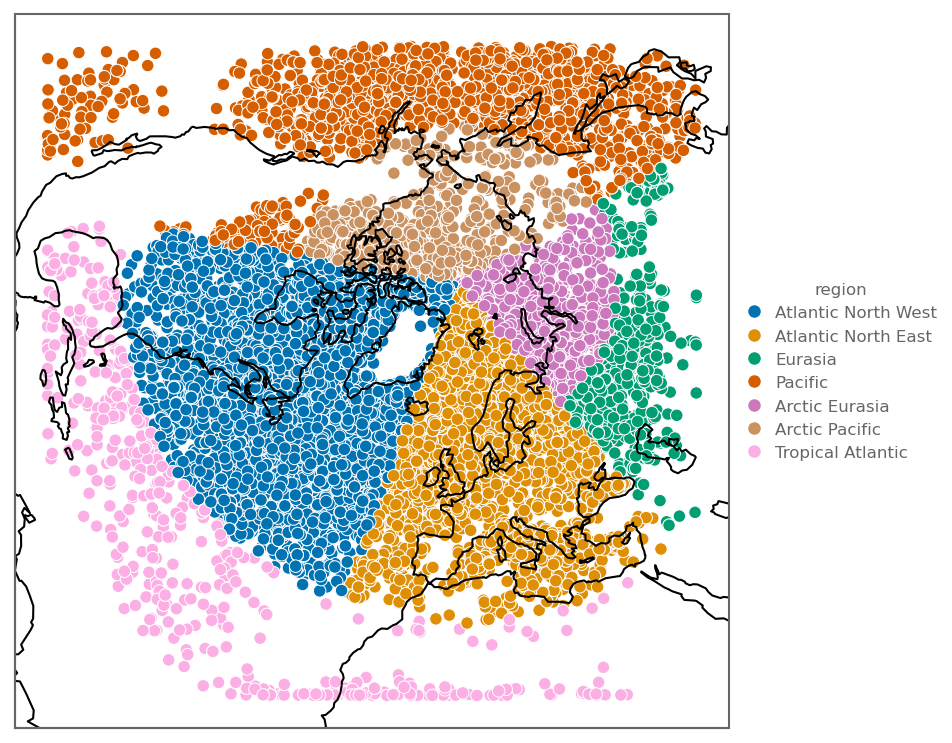

In [964]:
plot = sns.relplot(df_blob_cycs.dropna(), x='x', y='y', hue='region',  hue_order=['Atlantic North West','Atlantic North East',
       'Eurasia', 'Pacific', 'Arctic Eurasia','Arctic Pacific', 
       'Tropical Atlantic'], facet_kws=dict(subplot_kws=dict(projection=proj)))

plot.axes[0,0].coastlines()

/tmp/ipykernel_59320/3376142506.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_cycs = df_blob_cycs.reset_index().set_index('cyclones').groupby(['timestep_past','time_of_event']).apply(lambda x:x.loc[x.attributions.idxmax()].region).rename('region').reset_index()
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/seaborn/_core/moves.py:256: FutureWarning: using <function <lambda> at 0x7fe872ec6340> in Series.agg cannot aggregate and has been deprecated. Use Series.transform to keep behavior unchanged.
  df[var] = df[var] / denom_data.agg(self.func)
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/seaborn/_core/moves.py:256: FutureWarning: u

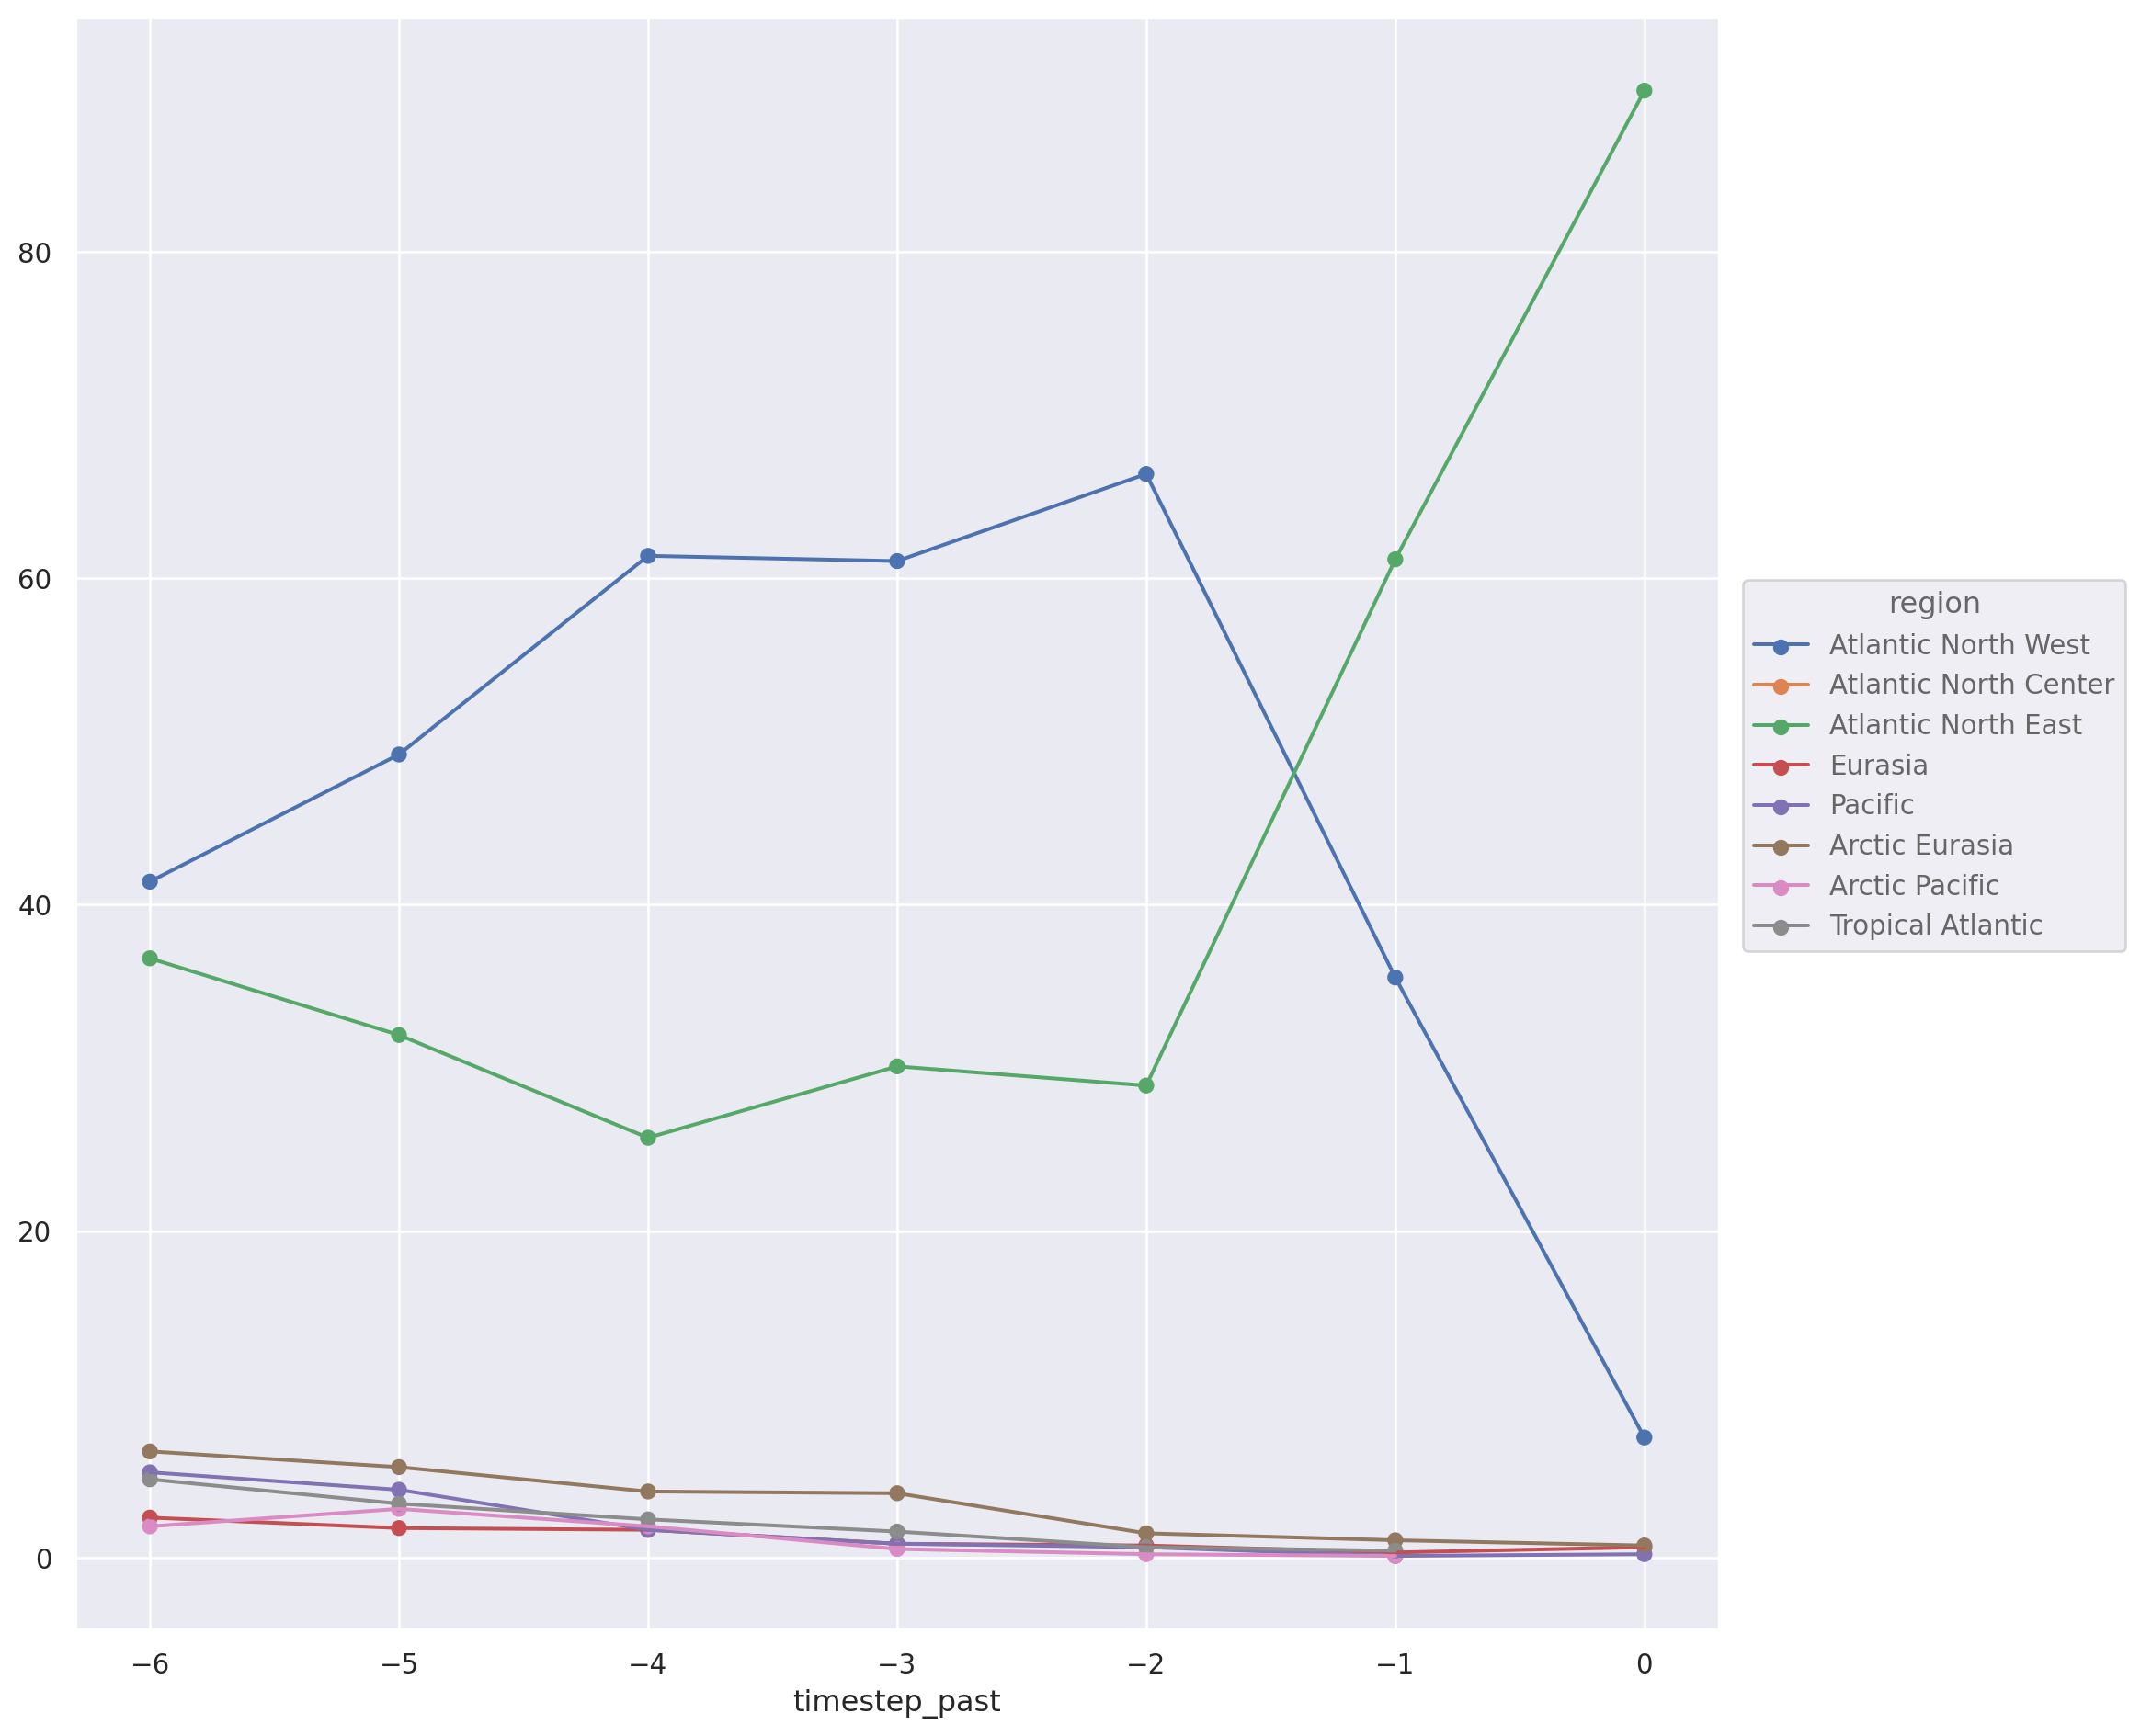

In [965]:
top_cycs = df_blob_cycs.reset_index().set_index('cyclones').groupby(['timestep_past','time_of_event']).apply(lambda x:x.loc[x.attributions.idxmax()].region).rename('region').reset_index()
top_cycs

(so.Plot(top_cycs, x='timestep_past', color='region')
 .add(so.Line(), so.Count(), so.Norm(func=lambda x:937, percent=True))
 .add(so.Dot(), so.Count(), so.Norm(func=lambda x:937, percent=True))
#  .facet(col='category')
 .scale(color=so.Nominal(order=['Atlantic North West', 'Atlantic North Center' ,'Atlantic North East',
       'Eurasia', 'Pacific', 'Arctic Eurasia','Arctic Pacific', 
       'Tropical Atlantic']))

 .layout(size=(10,10))
 )

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/seaborn/_core/moves.py:256: FutureWarning: using <function <lambda> at 0x7fe88946fba0> in Series.agg cannot aggregate and has been deprecated. Use Series.transform to keep behavior unchanged.
  df[var] = df[var] / denom_data.agg(self.func)
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/seaborn/_core/moves.py:256: FutureWarning: using <function <lambda> at 0x7fe88946e340> in Series.agg cannot aggregate and has been deprecated. Use Series.transform to keep behavior unchanged.
  df[var] = df[var] / denom_data.agg(self.func)


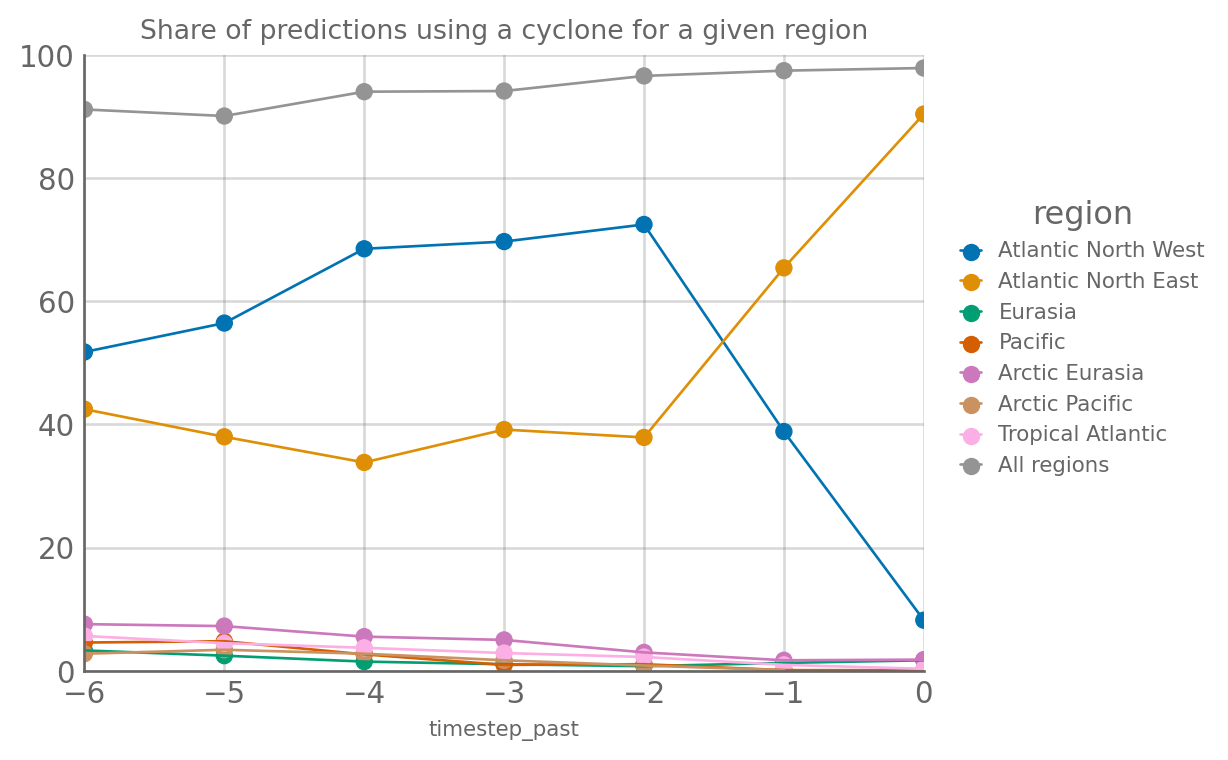

In [966]:
df_counts = df_blob_cycs.reset_index().query("category=='large positive'").groupby(['time_of_event','timestep_past','region']).msl.count().reset_index()
df_all_counts = df_blob_cycs.reset_index().query("category=='large positive'").groupby(['time_of_event','timestep_past']).msl.count().reset_index()
df_all_counts['region'] = 'All regions'
df_counts = pd.concat([df_counts, df_all_counts])

(so.Plot(df_counts, x='timestep_past', color='region')
 .add(so.Line(), so.Count(), so.Norm(func=lambda x:937, percent=True))
#  .add(so.Line(linewidth=3), so.Count(), so.Norm(func=lambda x:937, percent=True), data=df_all_counts)
 .add(so.Dot(), so.Count(), so.Norm(func=lambda x:937, percent=True))
#  .facet(col='category')
 .scale(color=so.Nominal(order=['Atlantic North West','Atlantic North East',
       'Eurasia', 'Pacific', 'Arctic Eurasia','Arctic Pacific', 
       'Tropical Atlantic','All regions']))

 .layout(size=(5,4))
 .limit(x=(-6,0), y=(0,100))
 .label(title='Share of predictions using a cyclone for a given region', )
  .theme(plt.style.library["robin"])
 .theme({'axes.grid':True, 'grid.color':'.5','grid.linestyle':'-', 'grid.alpha':.3})
 )



/tmp/ipykernel_59320/719375370.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df__ = df_.groupby(['timestep_past','time_of_event']).apply(lambda x:x.loc[x.attributions.idxmax()][['is_cyclone','category']]).reset_index().groupby(['timestep_past', 'is_cyclone']).count().reset_index()


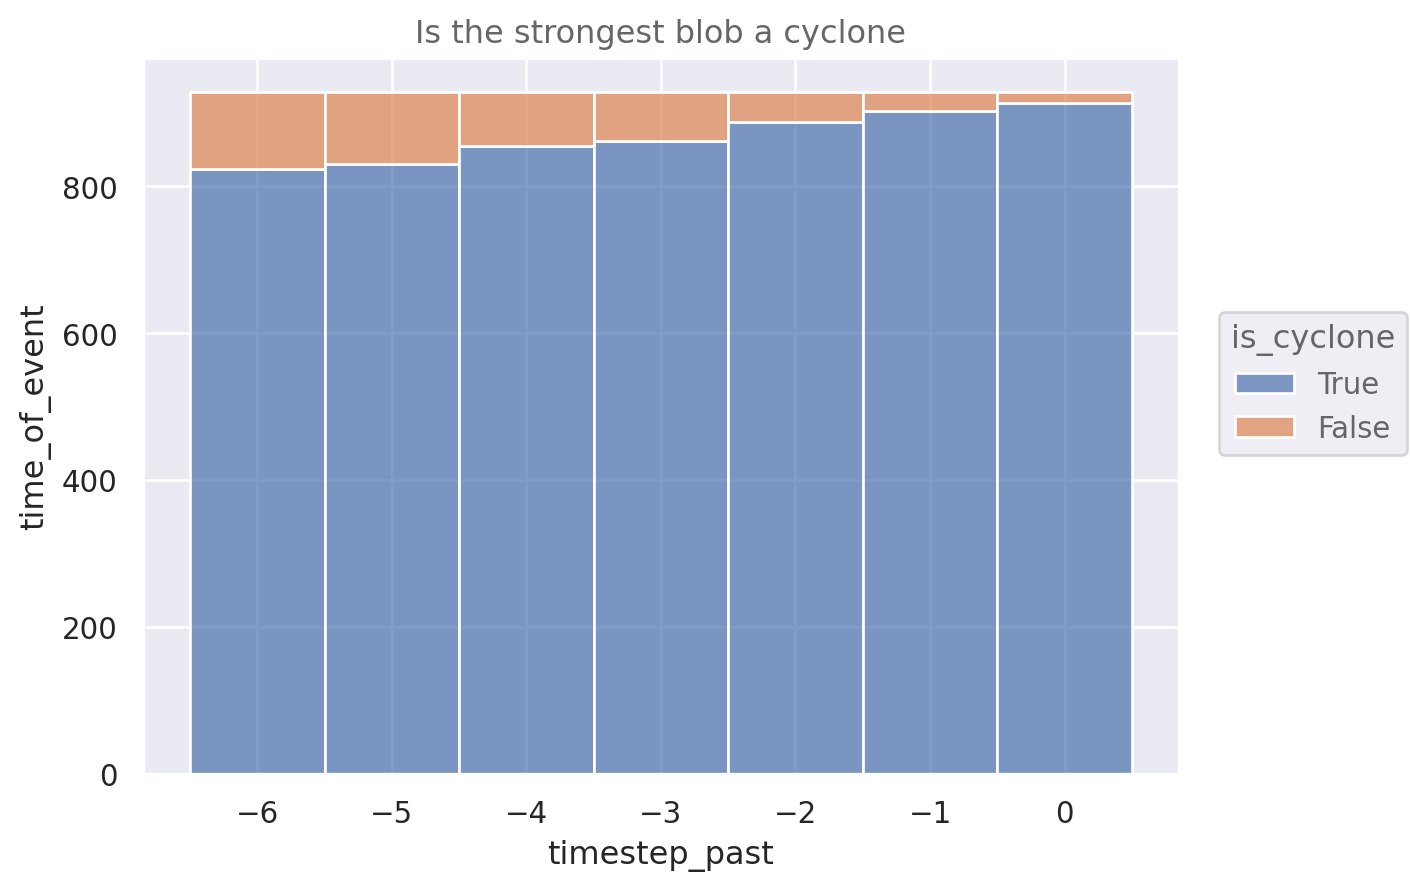

In [967]:
df__ = df_.groupby(['timestep_past','time_of_event']).apply(lambda x:x.loc[x.attributions.idxmax()][['is_cyclone','category']]).reset_index().groupby(['timestep_past', 'is_cyclone']).count().reset_index()
(so.Plot(df__[::-1], x='timestep_past',y='time_of_event', color='is_cyclone')
.add(so.Bars(), so.Stack())
 .label(title='Is the strongest blob a cyclone')
)
# df__

In [777]:
df__

,timestep_past,category,time_of_event,is_cyclone
0,-6,large neutral,12,12
1,-6,large positive,909,909
2,-6,small blob,7,7
3,-5,large neutral,20,20
4,-5,large positive,901,901
5,-5,small blob,7,7
6,-4,large neutral,12,12
7,-4,large positive,913,913
8,-4,small blob,3,3
9,-3,large neutral,7,7


In [782]:
df__

,timestep_past,time_of_event,0
0,-6,1979-01-07,True
1,-6,1979-03-03,True
2,-6,1979-03-04,True
3,-6,1979-03-05,True
4,-6,1979-08-14,True
...,...,...,...
6491,0,2024-12-01,True
6492,0,2024-12-13,True
6493,0,2024-12-15,True
6494,0,2024-12-18,True


/tmp/ipykernel_59320/4005065797.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df__ = df_.groupby(['timestep_past','time_of_event']).apply(lambda x:'large positive' in x.category.values).rename('large positive blob').reset_index()#.groupby(['timestep_past', 'category']).count().reset_index()


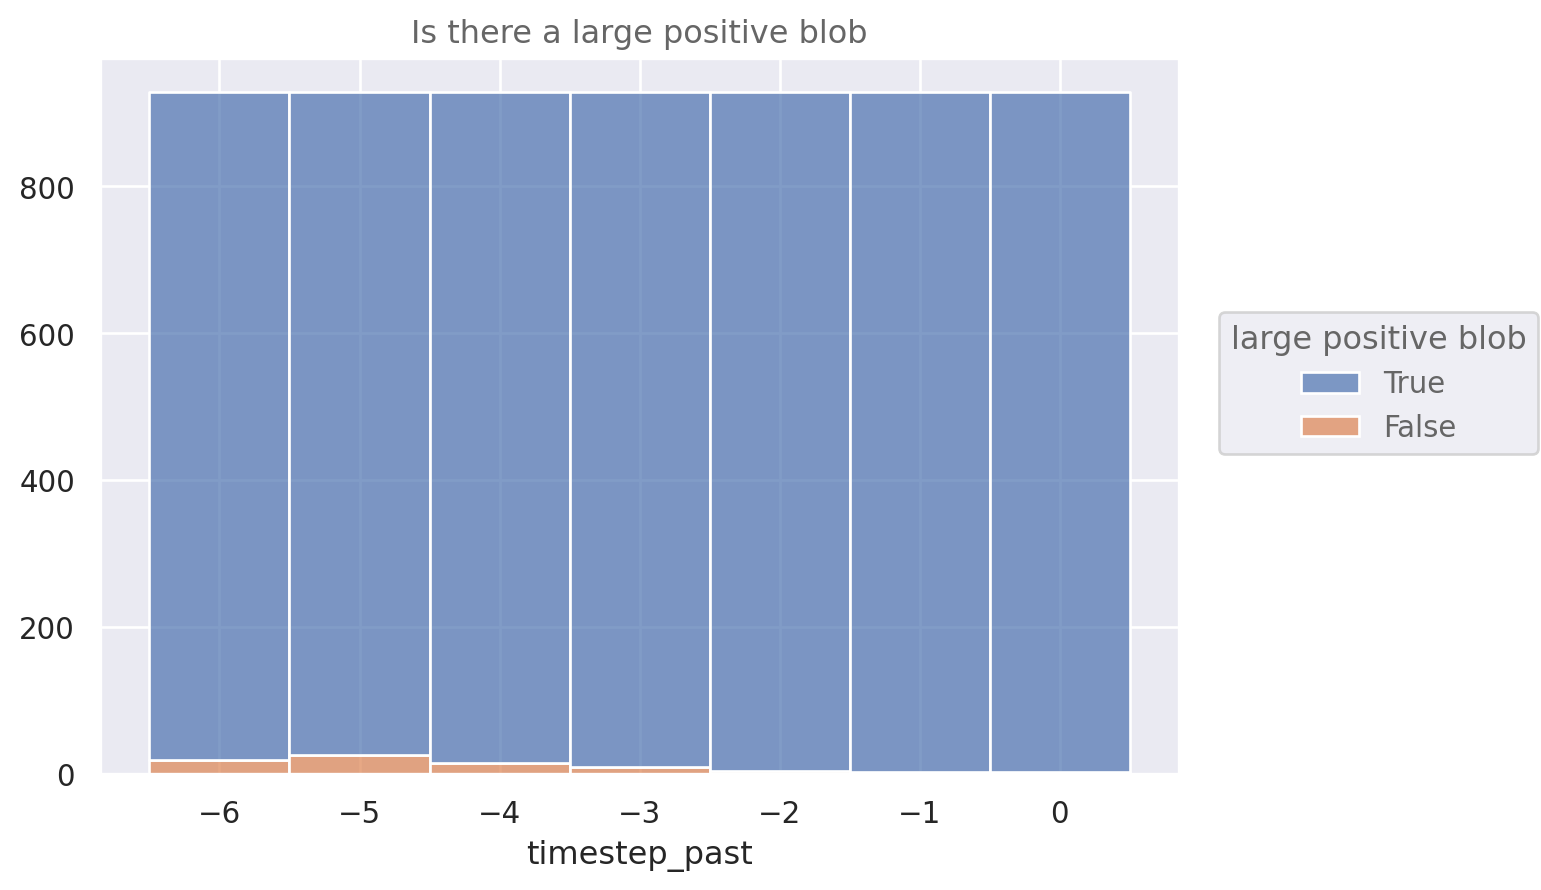

In [788]:
df__ = df_.groupby(['timestep_past','time_of_event']).apply(lambda x:'large positive' in x.category.values).rename('large positive blob').reset_index()#.groupby(['timestep_past', 'category']).count().reset_index()
(so.Plot(df__, x='timestep_past', color='large positive blob')
.add(so.Bars(), so.Count(),so.Stack())
 .label(title='Is there a large positive blob')
)
# df__

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/seaborn/_core/moves.py:256: FutureWarning: using <function <lambda> at 0x7fe8635a8220> in Series.agg cannot aggregate and has been deprecated. Use Series.transform to keep behavior unchanged.
  df[var] = df[var] / denom_data.agg(self.func)
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/seaborn/_core/moves.py:256: FutureWarning: using <function <lambda> at 0x7fe8503fb920> in Series.agg cannot aggregate and has been deprecated. Use Series.transform to keep behavior unchanged.
  df[var] = df[var] / denom_data.agg(self.func)


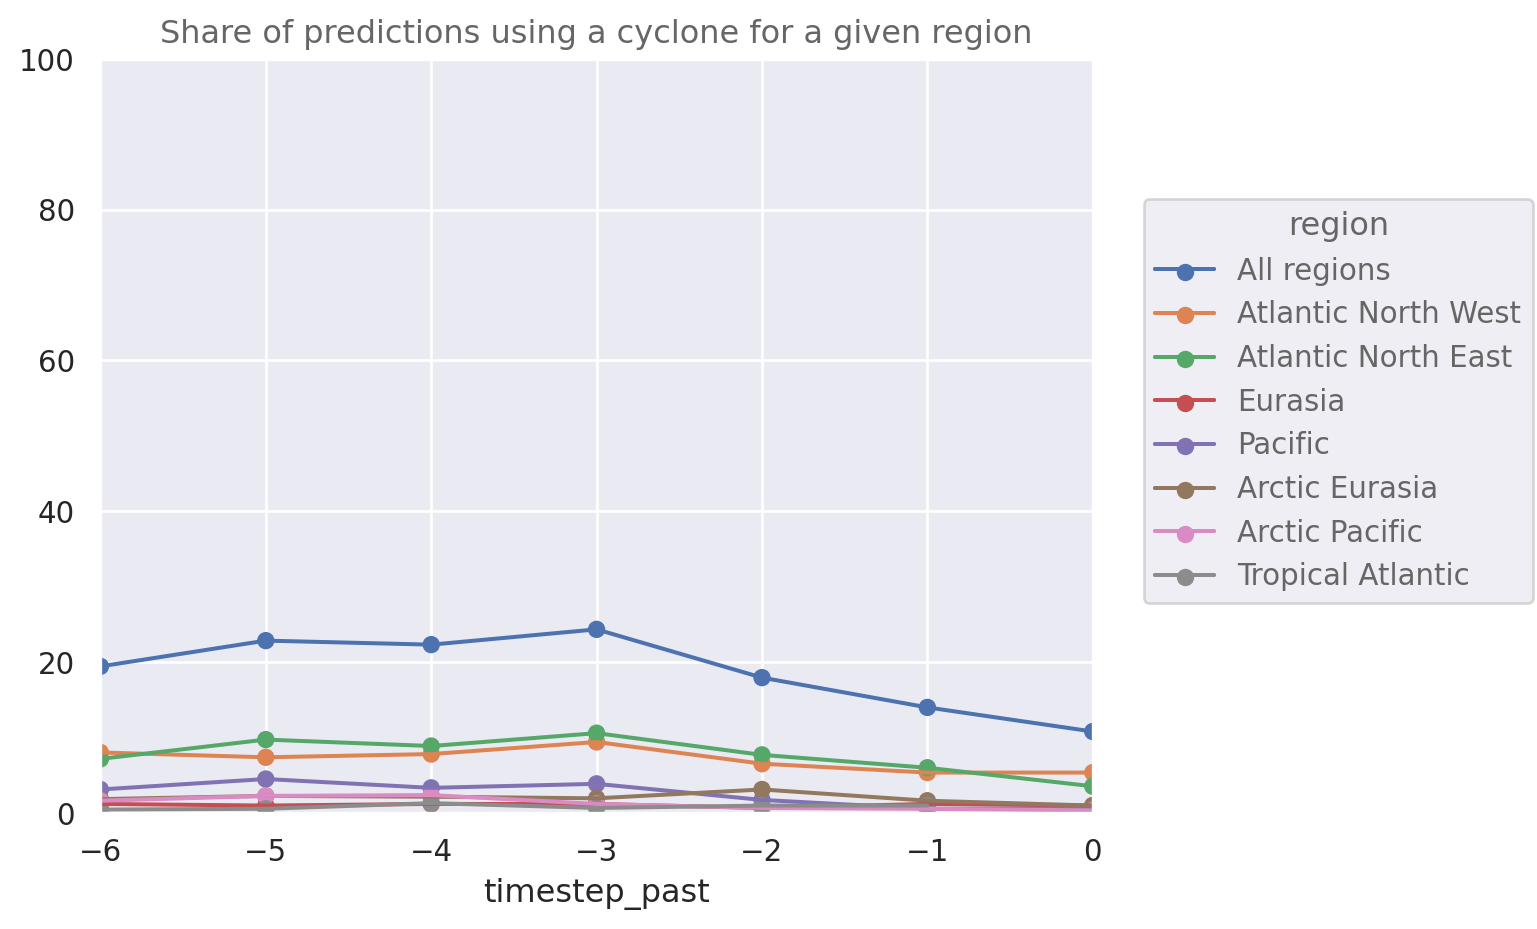

In [601]:
df_counts = df_blob_cycs.reset_index().query("category=='large neutral'").groupby(['time_of_event','timestep_past','region']).msl.count().reset_index()
df_all_counts = df_blob_cycs.reset_index().query("category=='large neutral'").groupby(['time_of_event','timestep_past']).msl.count().reset_index()
df_all_counts['region'] = 'All regions'
df_counts = pd.concat([df_counts, df_all_counts])

(so.Plot(df_counts, x='timestep_past', color='region')
 .add(so.Line(), so.Count(), so.Norm(func=lambda x:937, percent=True))
 .add(so.Line(), so.Count(),data=df_all_counts)
 .add(so.Dot(), so.Count(), so.Norm(func=lambda x:937, percent=True))
#  .facet(col='category')
 .scale(color=so.Nominal(order=['All regions','Atlantic North West','Atlantic North East',
       'Eurasia', 'Pacific', 'Arctic Eurasia','Arctic Pacific', 
       'Tropical Atlantic']))

 .layout(size=(6,5))
 .limit(x=(-6,0), y=(0,100))
 .label(title='Share of predictions using a cyclone for a given region', )
 )



In [421]:
df_blob_cycs.groupby('region').category.count()/df_blob_cycs.groupby('region').msl.count()

region
Arctic Eurasia         0.040772
Arctic Pacific         0.016648
Atlantic North East    0.102129
Atlantic North West    0.071365
Eurasia                0.028882
Pacific                0.021775
Tropical Atlantic      0.034451
dtype: float64

In [163]:
df_.rename(columns=dict(cyclones='track_id')).set_index(['track_id','date']).reset_index().groupby(['track_id','date']).attributions.count().value_counts()

attributions
1    10390
2     3168
3      893
4      291
5       67
6       10
7        2
Name: count, dtype: int64

## Number of blobs per prediction

<Axes: xlabel='geometry', ylabel='timestep_past'>

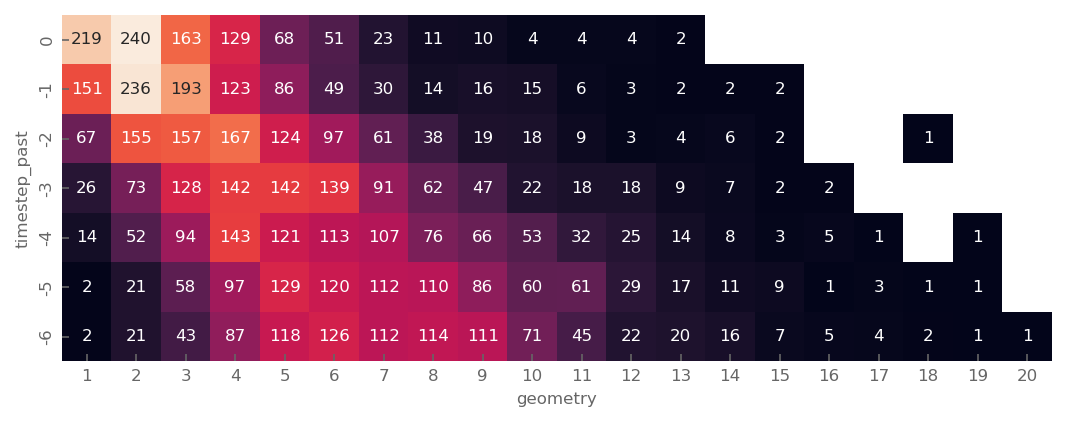

In [536]:
fig, axs = plt.subplots(figsize=(10,3))
sns.heatmap(df_.groupby(['timestep_past','time_of_event']).geometry.count().reset_index().groupby('timestep_past').geometry.value_counts().unstack().iloc[::-1], square=True, annot=True, cbar=False, fmt='.0f')

## Number of blobs per prediction without small ones

<Axes: xlabel='geometry', ylabel='timestep_past'>

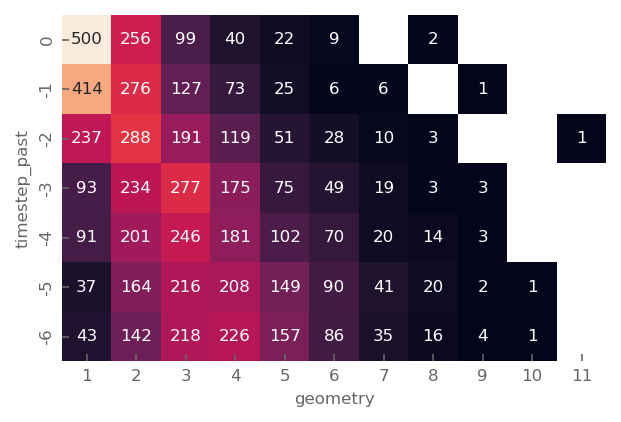

In [540]:
fig, axs = plt.subplots(figsize=(10,3))
sns.heatmap(df_.loc[np.abs(df_.segment_size)>5e5].groupby(['timestep_past','time_of_event']).geometry.count().reset_index().groupby('timestep_past').geometry.value_counts().unstack().iloc[::-1], square=True, annot=True, cbar=False, fmt='.0f')